In [ ]:
!pip install -q xgboost shap imbalanced-learn openpyxl kaggle
print('All packages installed!')

All packages installed!


In [ ]:
import os, json

os.makedirs('/root/.kaggle', exist_ok=True)
kaggle_creds = {
    "username": "adityapaldevops",
    "key":      "d49e1a103413bbb629e115b589f07154"
}
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_creds, f)
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print('Kaggle credentials set.')

DOWNLOAD_DIR = '/content/phishing_data'
os.makedirs(DOWNLOAD_DIR, exist_ok=True)
!kaggle datasets download -d yasserhessein/multi-dataset-phishing -p {DOWNLOAD_DIR} --unzip

print(f'\n Downloaded files:')
for f in os.listdir(DOWNLOAD_DIR):
    sz = os.path.getsize(os.path.join(DOWNLOAD_DIR, f))
    print(f'   {f}  ({sz/1024:.1f} KB)')

Kaggle credentials set.
Dataset URL: https://www.kaggle.com/datasets/yasserhessein/multi-dataset-phishing
License(s): MIT
100% 431k/431k [00:00<00:00, 627kB/s]


 Downloaded files:
   Phishing detection  (4.0 KB)


In [ ]:
import pandas as pd
import numpy as np
import warnings, glob
warnings.filterwarnings('ignore')

DOWNLOAD_DIR = '/content/phishing_data'
all_files = sorted(
    glob.glob(os.path.join(DOWNLOAD_DIR, '**/*.csv'),  recursive=True) +
    glob.glob(os.path.join(DOWNLOAD_DIR, '**/*.xlsx'), recursive=True),
    key=os.path.getsize, reverse=True
)
print('Detected files:')
for f in all_files:
    print(f'   {f}  ({os.path.getsize(f)/1024:.1f} KB)')

DATASET_PATH = all_files[0]
print(f'\n Loading: {DATASET_PATH}')

df_raw = pd.read_csv(DATASET_PATH, low_memory=False) if DATASET_PATH.endswith('.csv')          else pd.read_excel(DATASET_PATH)

print(f'\n Shape  : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
print(f'Columns : {list(df_raw.columns[:10])} ...')
df_raw.head(3)

Detected files:
   /content/phishing_data/Phishing detection/Zieni_Dataset for phishing detection.csv  (1494.6 KB)

 Loading: /content/phishing_data/Phishing detection/Zieni_Dataset for phishing detection.csv

 Shape  : 10,000 rows × 75 columns
Columns : ['num_dots_url', 'num_hyph_url', 'num_underline_url', 'num_slash_url', 'num_questionmark_url', 'num_equal_url', 'at_sign_url', 'num_and_url', 'num_exclamation_url', 'num_space_url'] ...


,num_dots_url,num_hyph_url,num_underline_url,num_slash_url,num_questionmark_url,num_equal_url,at_sign_url,num_and_url,num_exclamation_url,num_space_url,...,tilde_param,num_comma_param,num_plus_param,num_asterisk_param,num_dollar_param,num_percent_param,length_param,tld_in_param,num_param,phishing
0,1,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,1,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
# ── Detect label column ──────────────────────────────────────
LABEL_CANDIDATES = ['label','Label','type','Type','class','Class',
                    'phishing','target','Result','Category']
label_col = None
for c in LABEL_CANDIDATES:
    if c in df_raw.columns:
        label_col = c
        break
if label_col is None:
    label_col = df_raw.columns[-1]

print(f'   Label column : \'{label_col}\'')
print(f'   Raw unique values : {sorted(df_raw[label_col].dropna().unique())}')
print(f'\n   Value counts:')
print(df_raw[label_col].value_counts())

# ── Missing values ────────────────────────────────────────────
missing = df_raw.isnull().sum()
missing = missing[missing > 0]
print(f'\n Missing values: {len(missing)} columns affected')
if len(missing): print(missing)

   Label column : 'phishing'
   Raw unique values : [np.int64(0), np.int64(1)]

   Value counts:
phishing
0    5000
1    5000
Name: count, dtype: int64

 Missing values: 0 columns affected


In [ ]:
# ── Drop string/metadata columns ────────────────────────────
cols_to_drop = []
for col in df_raw.columns:
    if col == label_col:
        continue
    if df_raw[col].dtype == object:
        cols_to_drop.append(col)

print(f' Dropping {len(cols_to_drop)} non-numeric columns: {cols_to_drop}')
df = df_raw.drop(columns=cols_to_drop, errors='ignore').copy()

# ── Coerce all remaining to numeric ──────────────────────────
for col in df.columns:
    if col != label_col:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df.fillna(df.median(numeric_only=True), inplace=True)

# ── BUG 1 FIX: Binary label encoding ─────────────────────────
raw_labels = df[label_col].astype(str).str.strip().str.lower()
unique_raw = raw_labels.unique()
print(f'\n Unique raw labels (normalized): {sorted(unique_raw)}')

# Phishing positive class keywords
PHISHING_KEYWORDS = {'phishing', '1', 'phish', 'phish_url', 'malicious'}
# Everything else = benign/negative

df['label_binary'] = raw_labels.apply(
    lambda x: 1 if any(kw in x for kw in PHISHING_KEYWORDS) else 0
)

print(f'\n Binary label mapping:')
for raw, binary in zip(raw_labels.unique(), df['label_binary'][raw_labels.map(dict(zip(raw_labels.unique(), raw_labels.unique()))).index].unique()):
    pass  # already mapped

mapping_check = pd.DataFrame({'raw': raw_labels, 'binary': df['label_binary']})
print(mapping_check.drop_duplicates('raw').sort_values('raw').to_string(index=False))
print(f'\n   Label 0 (Non-Phishing): {(df["label_binary"]==0).sum():,}')
print(f'   Label 1 (Phishing)    : {(df["label_binary"]==1).sum():,}')

LABEL_COL = 'label_binary'
X_full = df.drop(columns=[label_col, 'label_binary'], errors='ignore')
y_full = df['label_binary'].astype(int)
feature_names = list(X_full.columns)

print(f'\n Final feature count : {len(feature_names)}')
print(f' Class ratio         : {y_full.mean():.3f} (phishing rate)')

 Dropping 0 non-numeric columns: []

 Unique raw labels (normalized): ['0', '1']

 Binary label mapping:
raw  binary
  0       0
  1       1

   Label 0 (Non-Phishing): 5,000
   Label 1 (Phishing)    : 5,000

 Final feature count : 74
 Class ratio         : 0.500 (phishing rate)


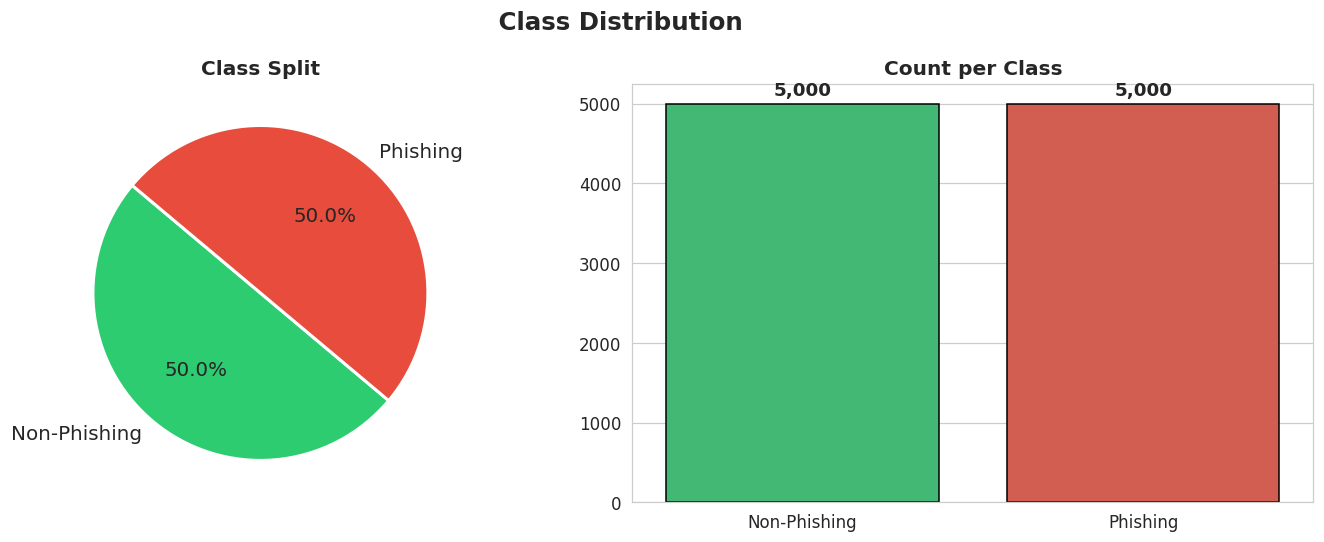

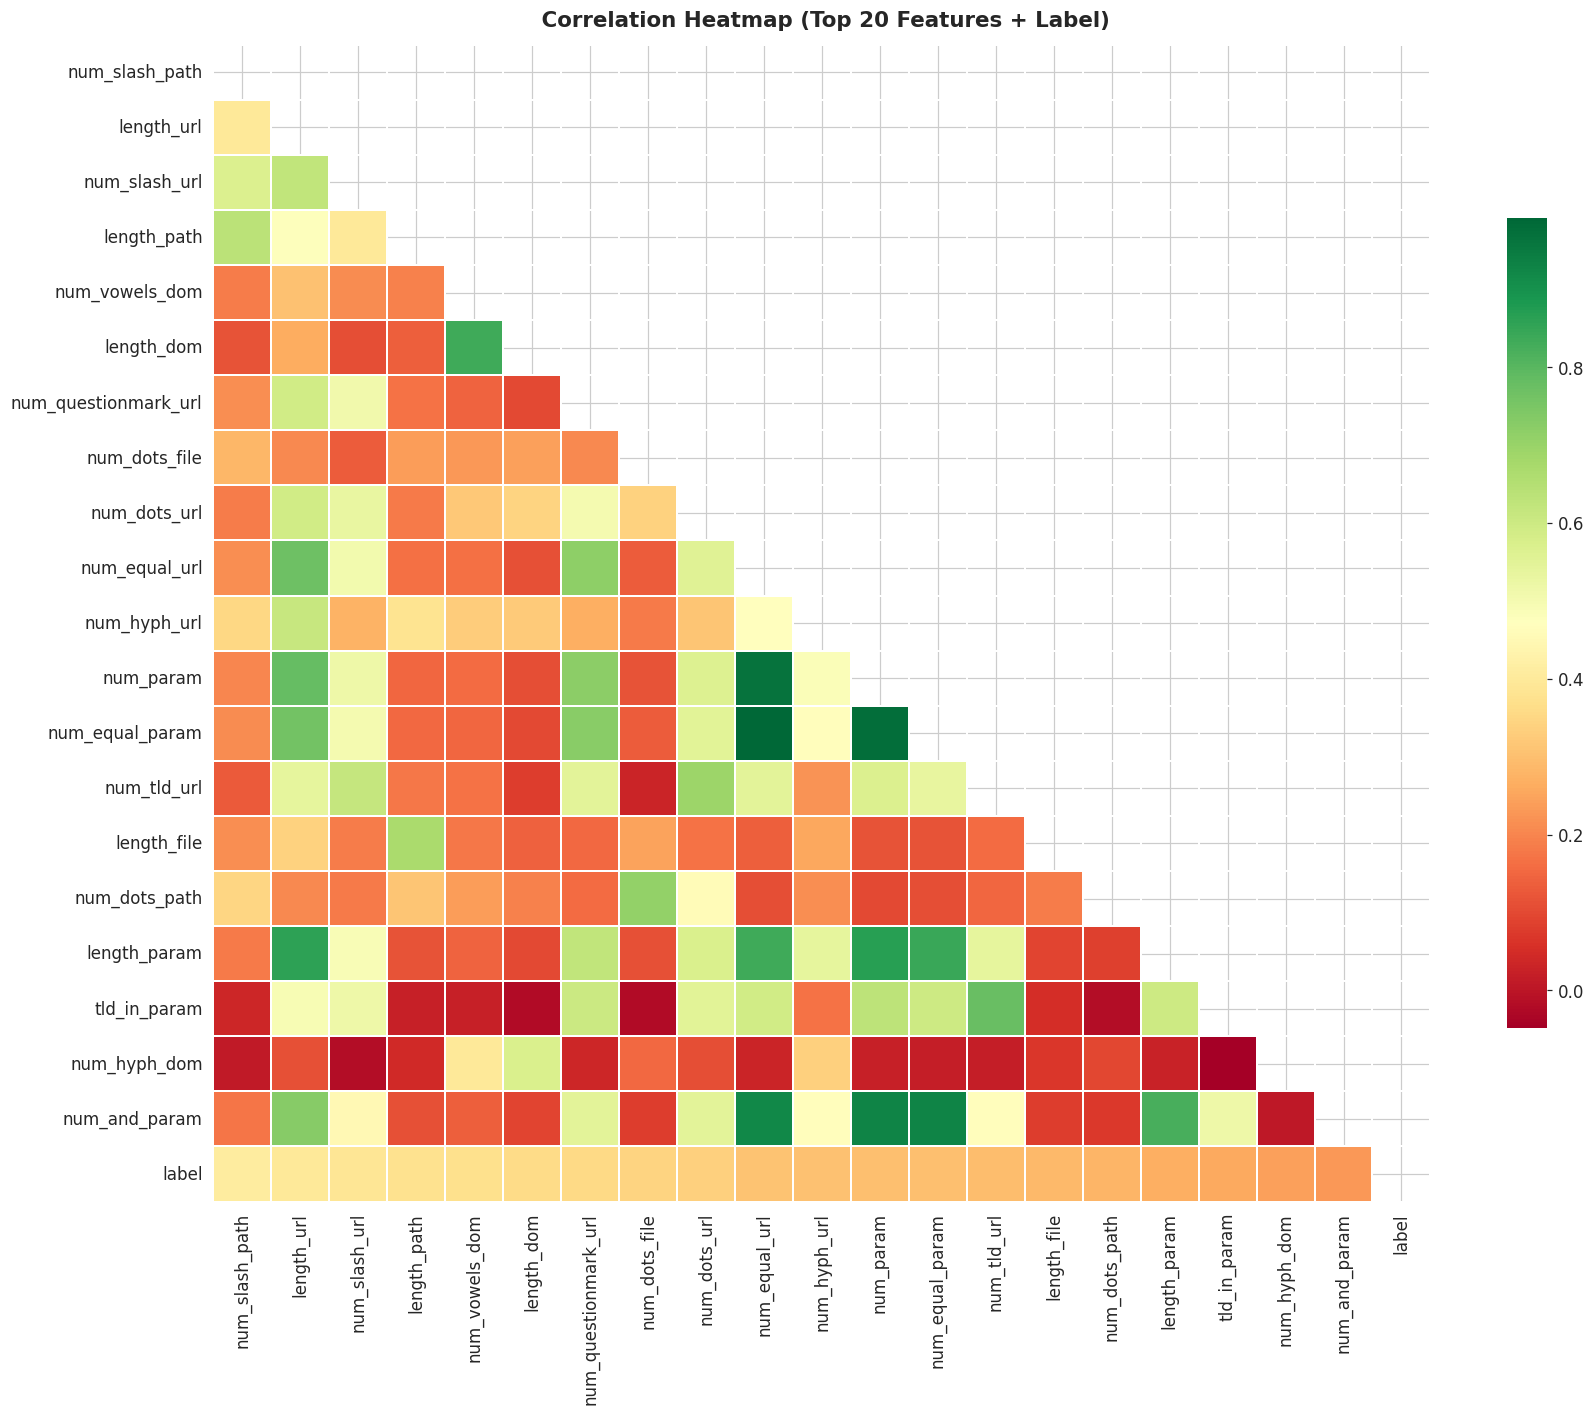

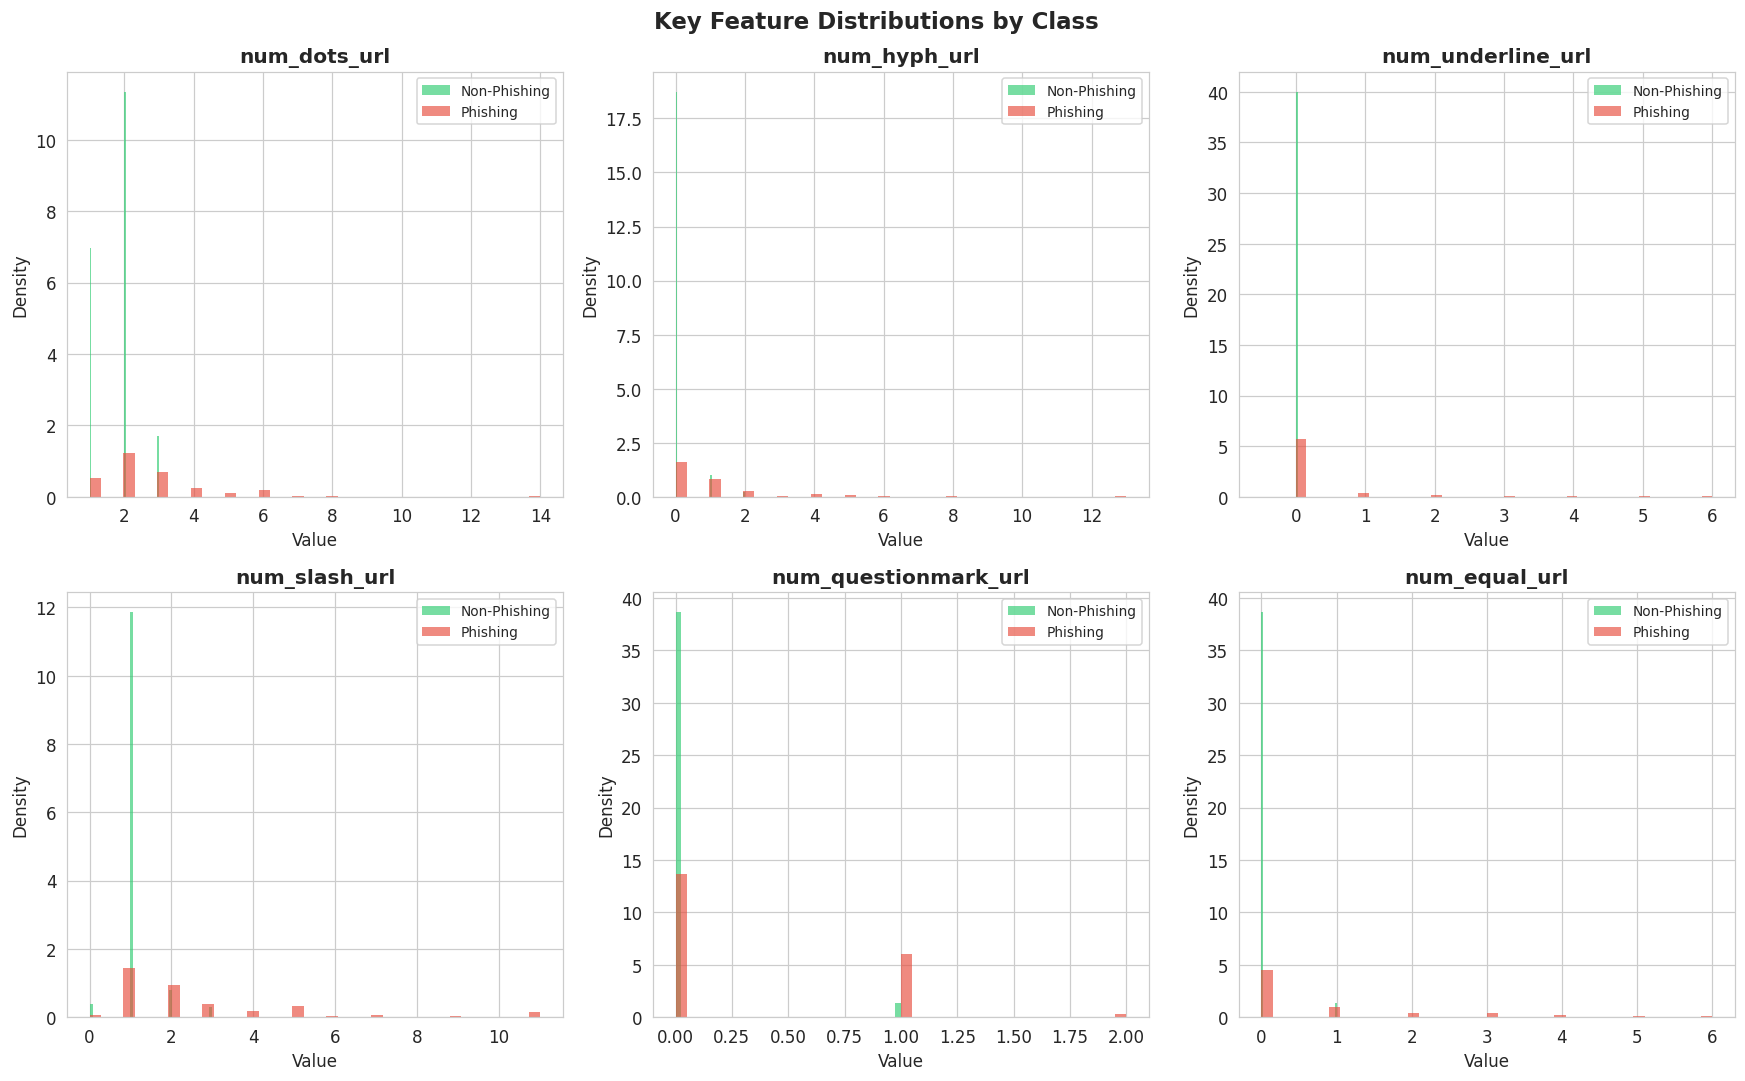

 EDA complete!


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 11, 'figure.dpi': 110})
PALETTE = ['#2ECC71', '#E74C3C']   # 0=Non-Phishing=Green, 1=Phishing=Red
LABEL_NAMES = {0: 'Non-Phishing', 1: 'Phishing'}

# ── 6A. Class Distribution ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(' Class Distribution', fontsize=16, fontweight='bold')

counts = y_full.value_counts().sort_index()
axes[0].pie(counts, labels=[LABEL_NAMES[i] for i in counts.index],
            colors=PALETTE, autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor':'white','linewidth':2}, textprops={'fontsize':13})
axes[0].set_title('Class Split', fontweight='bold')

sns.barplot(x=[LABEL_NAMES[i] for i in counts.index], y=counts.values,
            palette=PALETTE, ax=axes[1], edgecolor='black')
for bar, count in zip(axes[1].patches, counts.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+100,
                 f'{count:,}', ha='center', fontsize=12, fontweight='bold')
axes[1].set_title('Count per Class', fontweight='bold')
plt.tight_layout(); plt.savefig('eda_class_distribution.png', bbox_inches='tight'); plt.show()

# ── 6B. Correlation Heatmap ───────────────────────────────────
df_plot = X_full.copy(); df_plot['label'] = y_full
top_cols = df_plot.corr()['label'].abs().sort_values(ascending=False).head(21).index.tolist()
top_cols = [c for c in top_cols if c != 'label'][:20]; top_cols.append('label')
corr_mat = df_plot[top_cols].corr()
fig, ax = plt.subplots(figsize=(16,13))
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, mask=mask, cmap='RdYlGn', annot=False,
            linewidths=0.3, ax=ax, cbar_kws={'shrink':0.7})
ax.set_title(' Correlation Heatmap (Top 20 Features + Label)',
             fontsize=14, fontweight='bold', pad=12)
plt.tight_layout(); plt.savefig('eda_correlation_heatmap.png', bbox_inches='tight'); plt.show()

# ── 6C. Feature Distributions ────────────────────────────────
numeric_cols = X_full.select_dtypes(include='number').columns.tolist()
# Prefer URL-related feature names
url_prefs = [c for c in numeric_cols if any(k in c.lower() for k in
             ['url','length','digit','special','https','subdomain','dot','slash'])]
plot_cols = (url_prefs + [c for c in numeric_cols if c not in url_prefs])[:6]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(' Key Feature Distributions by Class', fontsize=15, fontweight='bold')
axes = axes.flatten()
for idx, col in enumerate(plot_cols):
    ax = axes[idx]
    for lbl, color in zip([0,1], PALETTE):
        vals = X_full.loc[y_full==lbl, col].dropna()
        vals = vals.clip(vals.quantile(0.01), vals.quantile(0.99))
        ax.hist(vals, bins=40, alpha=0.65, color=color,
                label=LABEL_NAMES[lbl], density=True, edgecolor='none')
    ax.set_title(col, fontweight='bold'); ax.legend(fontsize=9)
    ax.set_xlabel('Value'); ax.set_ylabel('Density')
for i in range(len(plot_cols), 6): axes[i].axis('off')
plt.tight_layout(); plt.savefig('eda_feature_distributions.png', bbox_inches='tight'); plt.show()
print(' EDA complete!')

In [ ]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.20,
    random_state=RANDOM_STATE, stratify=y_full
)
print(f'   Train: {X_train_raw.shape[0]:,}  |  Test: {X_test_raw.shape[0]:,}')
print(f'   Train label dist: {y_train.value_counts().to_dict()}')
print(f'   Test  label dist: {y_test.value_counts().to_dict()}')

   Train: 8,000  |  Test: 2,000
   Train label dist: {0: 4000, 1: 4000}
   Test  label dist: {0: 1000, 1: 1000}


In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.preprocessing import StandardScaler

# Perform feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled  = scaler.transform(X_test_raw)

counts_train = Counter(y_train)
ratio = min(counts_train.values()) / max(counts_train.values())
print(f'Before SMOTE: {dict(counts_train)}  (ratio={ratio:.3f})')

if ratio < 0.85:
    smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
    X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)
    print(f' After SMOTE: {Counter(y_train_bal)}')
else:
    X_train_bal, y_train_bal = X_train_scaled, y_train
    print(' Dataset balanced — SMOTE not needed.')

print(f'   Final training shape: {X_train_bal.shape}')

Before SMOTE: {0: 4000, 1: 4000}  (ratio=1.000)
 Dataset balanced — SMOTE not needed.
   Final training shape: (8000, 74)


 RFE selecting top 30 features...
 Selected 30 features: ['num_dots_url', 'num_hyph_url', 'num_underline_url', 'num_slash_url', 'num_questionmark_url', 'num_equal_url', 'num_and_url', 'hashtag_url', 'num_percent_url', 'num_tld_url', 'length_url', 'num_dots_dom', 'num_hyph_dom', 'num_vowels_dom', 'length_dom', 'num_dots_path', 'num_hyph_path', 'num_underline_path', 'num_slash_path', 'length_path', 'num_dots_file', 'num_hyph_file', 'length_file', 'num_dots_param', 'num_underline_param', 'num_equal_param', 'num_and_param', 'num_percent_param', 'length_param', 'num_param']


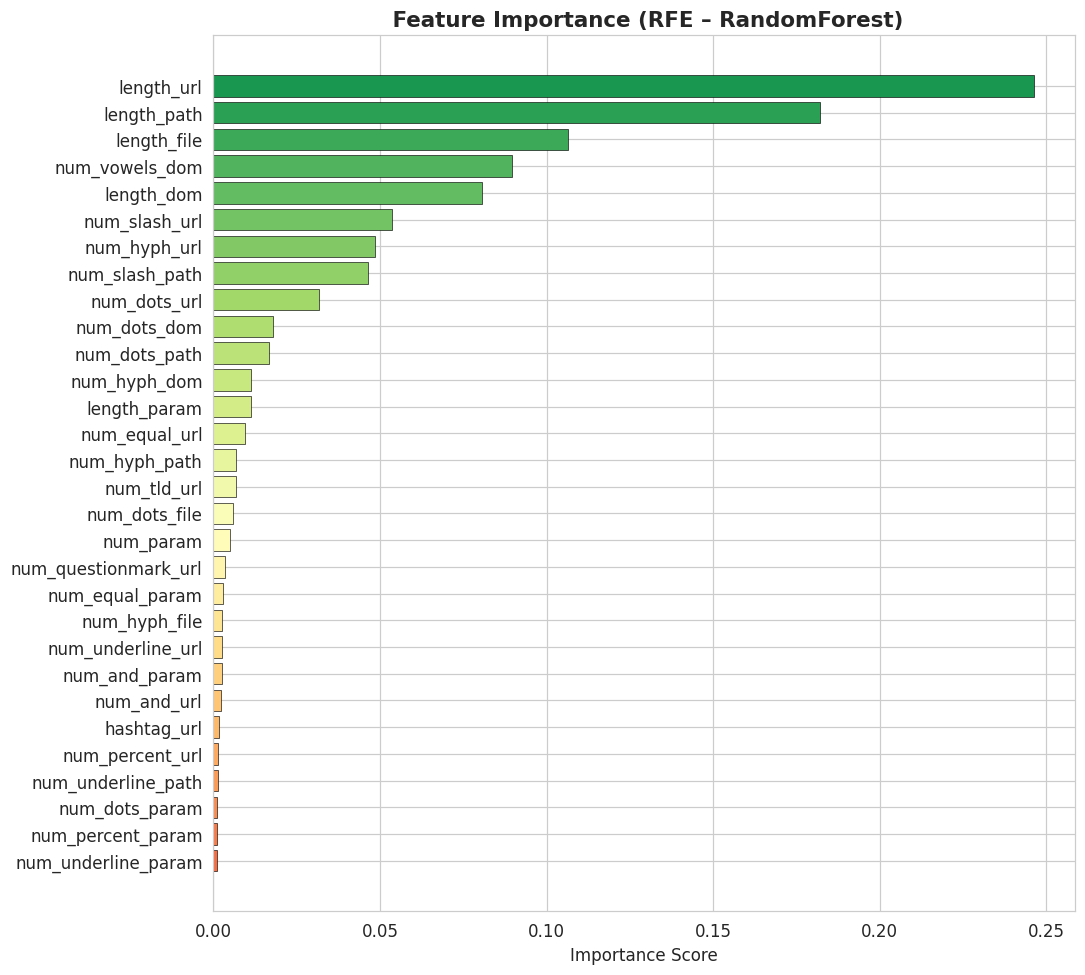

In [ ]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

N_FEATURES = min(30, X_train_bal.shape[1])
print(f' RFE selecting top {N_FEATURES} features...')

rf_rfe = RandomForestClassifier(n_estimators=50, random_state=RANDOM_STATE, n_jobs=-1)
rfe = RFE(estimator=rf_rfe, n_features_to_select=N_FEATURES, step=5)
rfe.fit(X_train_bal, y_train_bal)

selected_features = [feature_names[i] for i, s in enumerate(rfe.support_) if s]
X_train_sel = rfe.transform(X_train_bal)
X_test_sel  = rfe.transform(X_test_scaled)

print(f' Selected {len(selected_features)} features: {selected_features}')

# Feature importance plot
importances = rfe.estimator_.feature_importances_
feat_imp_df = pd.DataFrame({'Feature': selected_features,
                             'Importance': importances}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, max(6, len(selected_features)*0.3)))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(feat_imp_df)))
ax.barh(feat_imp_df['Feature'], feat_imp_df['Importance'],
        color=colors, edgecolor='black', linewidth=0.4)
ax.set_title(' Feature Importance (RFE – RandomForest)', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout(); plt.savefig('feature_importance.png', bbox_inches='tight'); plt.show()

Model                         Acc    Prec     Rec      F1     AUC
Logistic Regression        0.8500  0.8555  0.8500  0.8494  0.9280  (0.1s)
Random Forest              0.9035  0.9035  0.9035  0.9035  0.9625  (1.1s)
Gradient Boosting          0.9065  0.9070  0.9065  0.9065  0.9619  (2.2s)
SVM                        0.8830  0.8849  0.8830  0.8829  0.9397  (8.9s)
XGBoost                    0.9045  0.9048  0.9045  0.9045  0.9614  (0.6s)


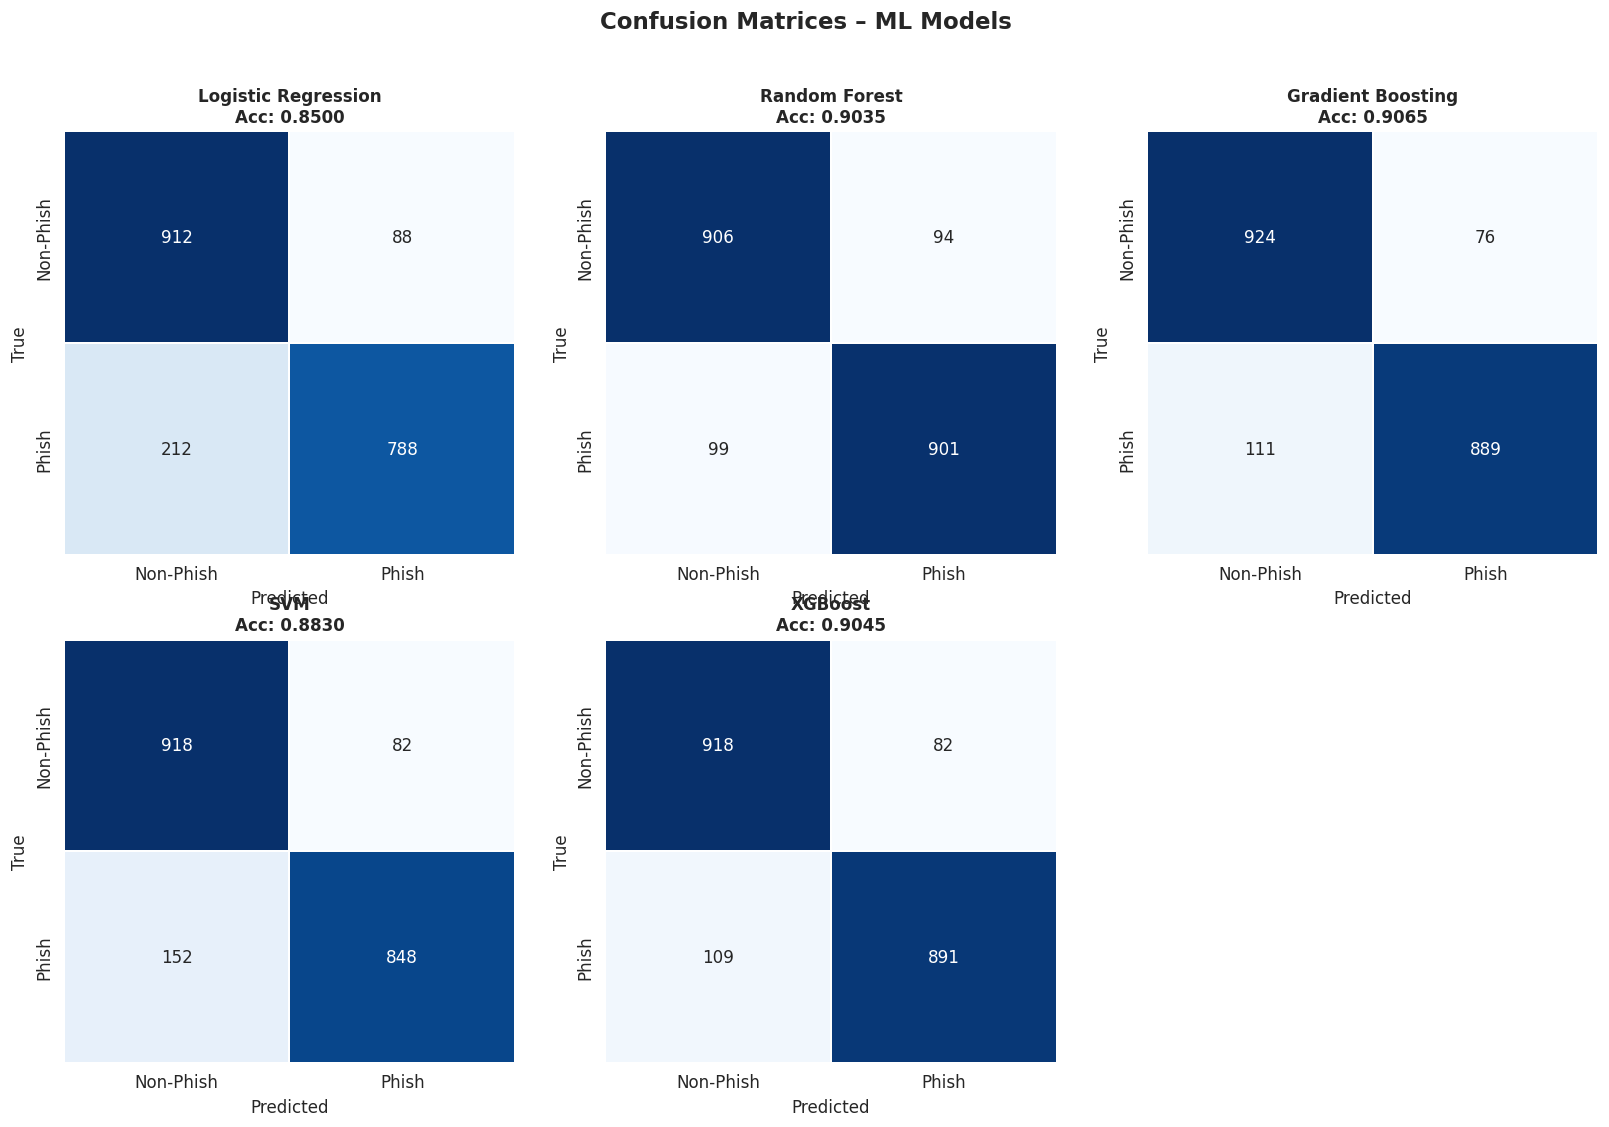

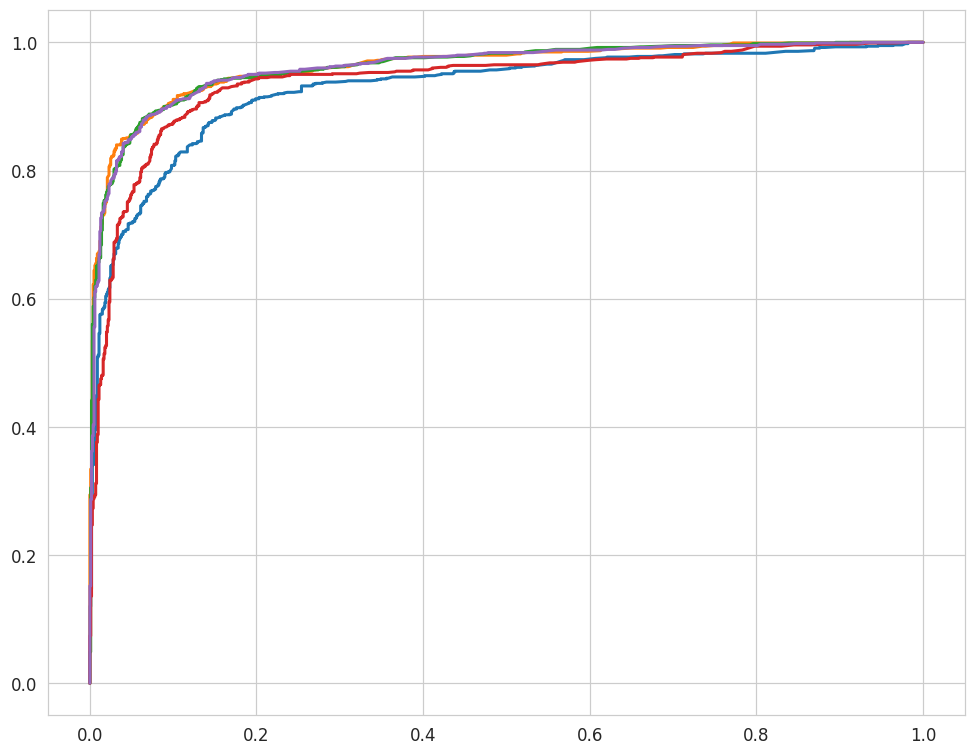

<Figure size 704x528 with 0 Axes>


 All ML models trained!


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve)
import time

# ── Model definitions ──────────────────────────────────────────
MODELS = {
    'Logistic Regression': LogisticRegression(
        max_iter=2000, random_state=RANDOM_STATE, C=1.0, solver='lbfgs'),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=15, random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=150, max_depth=5, learning_rate=0.1, random_state=RANDOM_STATE),
    'SVM': SVC(kernel='rbf', C=1.0, probability=True, random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        use_label_encoder=False, eval_metric='logloss',
        random_state=RANDOM_STATE, n_jobs=-1),
}

results = []
trained_models = {}
roc_data = {}

print('='*70)
print(f'{"Model":<25} {"Acc":>7} {"Prec":>7} {"Rec":>7} {"F1":>7} {"AUC":>7}')
print('='*70)

# ── Confusion matrix grid ─────────────────────────────────────
fig_cm, axes_cm = plt.subplots(2, 3, figsize=(18, 11))
axes_cm_flat = axes_cm.flatten()
fig_roc, ax_roc = plt.subplots(figsize=(9, 7))

for idx, (name, model) in enumerate(MODELS.items()):
    t0 = time.time()
    model.fit(X_train_sel, y_train_bal)
    trained_models[name] = model

    y_pred = model.predict(X_test_sel)
    y_prob = model.predict_proba(X_test_sel)[:, 1]

    # BUG 1 FIX: use average='weighted' for all classification metrics
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred,    average='weighted', zero_division=0)
    f1   = f1_score(y_test, y_pred,        average='weighted', zero_division=0)
    auc  = roc_auc_score(y_test, y_prob)

    elapsed = time.time() - t0
    results.append({'Model': name, 'Accuracy': acc, 'Precision': prec,
                    'Recall': rec, 'F1-Score': f1, 'ROC-AUC': auc, 'Time(s)': round(elapsed,2)})
    roc_data[name] = (y_prob, auc)

    print(f'{name:<25} {acc:>7.4f} {prec:>7.4f} {rec:>7.4f} {f1:>7.4f} {auc:>7.4f}  ({elapsed:.1f}s)')

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes_cm_flat[idx],
                xticklabels=['Non-Phish','Phish'], yticklabels=['Non-Phish','Phish'],
                linewidths=1, cbar=False)
    axes_cm_flat[idx].set_title(f'{name}\nAcc: {acc:.4f}', fontweight='bold', fontsize=11)
    axes_cm_flat[idx].set_xlabel('Predicted'); axes_cm_flat[idx].set_ylabel('True')

    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax_roc.plot(fpr, tpr, lw=2, label=f'{name} (AUC={auc:.4f})')

print('='*70)

# Unused subplot
axes_cm_flat[-1].axis('off')
fig_cm.suptitle('Confusion Matrices – ML Models', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.savefig('confusion_matrices_ml.png', bbox_inches='tight'); plt.show()

ax_roc.plot([0,1],[0,1],'k--',lw=1,label='Random')
ax_roc.set_xlabel('FPR', fontsize=12); ax_roc.set_ylabel('TPR', fontsize=12)
ax_roc.set_title('ROC Curves – ML Models', fontsize=14, fontweight='bold')
ax_roc.legend(fontsize=10); ax_roc.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('roc_curves_ml.png', bbox_inches='tight'); plt.show()

rf_model  = trained_models['Random Forest']
xgb_model = trained_models['XGBoost']
lr_model  = trained_models['Logistic Regression']
svm_model = trained_models['SVM']
print('\n All ML models trained!')

In [ ]:
from sklearn.model_selection import cross_val_score, GridSearchCV

print(' 5-Fold CV on Random Forest...')
cv_scores = cross_val_score(
    RandomForestClassifier(n_estimators=100, max_depth=15,
                           random_state=RANDOM_STATE, n_jobs=-1),
    X_train_sel, y_train_bal, cv=5, scoring='f1_weighted', n_jobs=-1)
print(f'   F1 per fold : {[f"{s:.4f}" for s in cv_scores]}')
print(f'   Mean F1     : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

print('\n GridSearchCV tuning XGBoost...')
param_grid = {
    'n_estimators': [100, 200],
    'max_depth':    [4, 6],
    'learning_rate':[0.05, 0.1],
}
xgb_cv = XGBClassifier(use_label_encoder=False, eval_metric='logloss',
                        random_state=RANDOM_STATE, n_jobs=-1)
grid_search = GridSearchCV(xgb_cv, param_grid, cv=3, scoring='roc_auc', n_jobs=-1, verbose=0)
grid_search.fit(X_train_sel, y_train_bal)

best_xgb     = grid_search.best_estimator_
best_params  = grid_search.best_params_
best_cv_auc  = grid_search.best_score_

print(f'   Best params  : {best_params}')
print(f'   CV AUC       : {best_cv_auc:.4f}')

y_pred_tuned = best_xgb.predict(X_test_sel)
y_prob_tuned = best_xgb.predict_proba(X_test_sel)[:,1]
print(f'   Test AUC     : {roc_auc_score(y_test, y_prob_tuned):.4f}')
print(f'   Test F1(w)   : {f1_score(y_test, y_pred_tuned, average="weighted"):.4f}')

# Update xgb with tuned version
xgb_model = best_xgb
trained_models['XGBoost'] = xgb_model

 5-Fold CV on Random Forest...
   F1 per fold : ['0.9087', '0.8956', '0.8974', '0.8881', '0.9000']
   Mean F1     : 0.8980 ± 0.0067

 GridSearchCV tuning XGBoost...
   Best params  : {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200}
   CV AUC       : 0.9585
   Test AUC     : 0.9614
   Test F1(w)   : 0.9045


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │         7,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,993 (207.00 KB)

 Trainable params: 52,097 (203.50 KB)

 Non-trainable params: 896 (3.50 KB)


 Training ANN (up to 100 epochs)...
Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 183ms/step - accuracy: 0.8071 - auc: 0.8711 - loss: 0.4463 - precision: 0.8298 - recall: 0.7728 - val_accuracy: 0.8410 - val_auc: 0.9240 - val_loss: 0.4915 - val_precision: 0.9241 - val_recall: 0.7430 - learning_rate: 0.0010
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8587 - auc: 0.9184 - loss: 0.3574 - precision: 0.8841 - recall: 0.8257 - val_accuracy: 0.8485 - val_auc: 0.9390 - val_loss: 0.4465 - val_precision: 0.9406 - val_recall: 0.7440 - learning_rate: 0.0010
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8686 - auc: 0.9276 - loss: 0.3384 - precision: 0.8875 - recall: 0.8443 - val_accuracy: 0.8545 - val_auc: 0.9428 - val_loss: 0.4056 - val_precision: 0.9382 - val_recall: 0.7590 - learning_rate: 0.0010
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8706 - auc: 0.9352 - loss: 0.3190 - precision: 0.8886 - recall: 0.8475 - val_accuracy: 0.8640 - val_

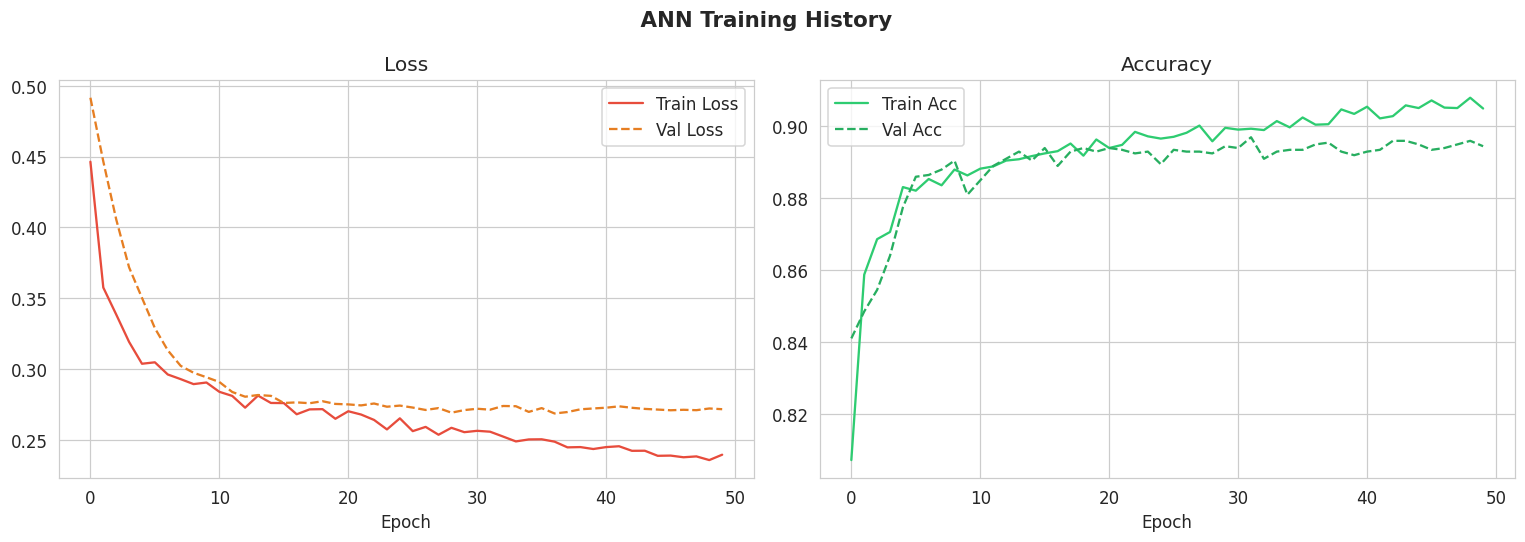


 ANN Results → Acc:0.8935  Prec:0.8974  Rec:0.8935  F1:0.8932  AUC:0.9536
   Epochs completed: 50


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

tf.random.set_seed(RANDOM_STATE)
n_features = X_train_sel.shape[1]

def build_ann(input_dim):
    inp = keras.Input(shape=(input_dim,))
    x = layers.Dense(256, activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    model = keras.Model(inp, out)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy',
                 keras.metrics.AUC(name='auc'),
                 keras.metrics.Precision(name='precision'),
                 keras.metrics.Recall(name='recall')]
    )
    return model

ann_model = build_ann(n_features)
ann_model.summary()

callbacks = [
    EarlyStopping(monitor='val_auc', mode='max', patience=15,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=7, min_lr=1e-6, verbose=1),
]

print('\n Training ANN (up to 100 epochs)...')
history = ann_model.fit(
    X_train_sel, y_train_bal,
    validation_data=(X_test_sel, y_test),
    epochs=100, batch_size=256,
    callbacks=callbacks, verbose=1
)

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14,5))
fig.suptitle(' ANN Training History', fontsize=14, fontweight='bold')
axes[0].plot(history.history['loss'],     label='Train Loss', color='#E74C3C')
axes[0].plot(history.history['val_loss'], label='Val Loss',   color='#E67E22', ls='--')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')
axes[1].plot(history.history['accuracy'],     label='Train Acc', color='#2ECC71')
axes[1].plot(history.history['val_accuracy'], label='Val Acc',   color='#27AE60', ls='--')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].set_xlabel('Epoch')
plt.tight_layout(); plt.savefig('ann_training_curves.png', bbox_inches='tight'); plt.show()

# ANN evaluation
y_prob_ann = ann_model.predict(X_test_sel, verbose=0).ravel()
y_pred_ann = (y_prob_ann >= 0.5).astype(int)

ann_acc  = accuracy_score(y_test, y_pred_ann)
ann_prec = precision_score(y_test, y_pred_ann, average='weighted', zero_division=0)
ann_rec  = recall_score(y_test, y_pred_ann,    average='weighted', zero_division=0)
ann_f1   = f1_score(y_test, y_pred_ann,        average='weighted', zero_division=0)
ann_auc  = roc_auc_score(y_test, y_prob_ann)

print(f'\n ANN Results → Acc:{ann_acc:.4f}  Prec:{ann_prec:.4f}  Rec:{ann_rec:.4f}  F1:{ann_f1:.4f}  AUC:{ann_auc:.4f}')
print(f'   Epochs completed: {len(history.history["loss"])}')

results.append({'Model':'ANN (Deep Learning)', 'Accuracy':ann_acc, 'Precision':ann_prec,
                'Recall':ann_rec, 'F1-Score':ann_f1, 'ROC-AUC':ann_auc, 'Time(s)':0})
roc_data['ANN'] = (y_prob_ann, ann_auc)

In [ ]:
from sklearn.ensemble import VotingClassifier, StackingClassifier

# ── Soft Voting ───────────────────────────────────────────────
print(' Training Soft Voting Classifier...')
voting_model = VotingClassifier(
    estimators=[
        ('rf',  RandomForestClassifier(n_estimators=200, max_depth=15,
                                        random_state=RANDOM_STATE, n_jobs=-1)),
        ('xgb', XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                               use_label_encoder=False, eval_metric='logloss',
                               random_state=RANDOM_STATE, n_jobs=-1)),
        ('svm', SVC(kernel='rbf', C=1.0, probability=True, random_state=RANDOM_STATE)),
    ],
    voting='soft', n_jobs=-1
)
voting_model.fit(X_train_sel, y_train_bal)

y_pred_vote = voting_model.predict(X_test_sel)
y_prob_vote = voting_model.predict_proba(X_test_sel)[:,1]
v = {
    'Model':'Voting Ensemble',
    'Accuracy': accuracy_score(y_test, y_pred_vote),
    'Precision':precision_score(y_test, y_pred_vote, average='weighted', zero_division=0),
    'Recall':   recall_score(y_test, y_pred_vote,    average='weighted', zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_vote,        average='weighted', zero_division=0),
    'ROC-AUC':  roc_auc_score(y_test, y_prob_vote),
    'Time(s)': 0
}
results.append(v); roc_data['Voting Ensemble'] = (y_prob_vote, v['ROC-AUC'])
print(f' Voting  → Acc:{v["Accuracy"]:.4f}  AUC:{v["ROC-AUC"]:.4f}')

# ── Stacking ──────────────────────────────────────────────────
print('\n Training Stacking Classifier...')
stacking_model = StackingClassifier(
    estimators=[
        ('rf',  RandomForestClassifier(n_estimators=100, max_depth=12,
                                        random_state=RANDOM_STATE, n_jobs=-1)),
        ('xgb', XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1,
                               use_label_encoder=False, eval_metric='logloss',
                               random_state=RANDOM_STATE, n_jobs=-1)),
        ('svm', SVC(kernel='rbf', C=0.5, probability=True, random_state=RANDOM_STATE)),
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    cv=5, n_jobs=-1
)
stacking_model.fit(X_train_sel, y_train_bal)

y_pred_stack = stacking_model.predict(X_test_sel)
y_prob_stack = stacking_model.predict_proba(X_test_sel)[:,1]
s = {
    'Model':'Stacking Ensemble',
    'Accuracy': accuracy_score(y_test, y_pred_stack),
    'Precision':precision_score(y_test, y_pred_stack, average='weighted', zero_division=0),
    'Recall':   recall_score(y_test, y_pred_stack,    average='weighted', zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_stack,        average='weighted', zero_division=0),
    'ROC-AUC':  roc_auc_score(y_test, y_prob_stack),
    'Time(s)': 0
}
results.append(s); roc_data['Stacking Ensemble'] = (y_prob_stack, s['ROC-AUC'])
print(f'    Stacking → Acc:{s["Accuracy"]:.4f}  AUC:{s["ROC-AUC"]:.4f}')

 Training Soft Voting Classifier...
 Voting  → Acc:0.9055  AUC:0.9615

 Training Stacking Classifier...
    Stacking → Acc:0.9095  AUC:0.9608


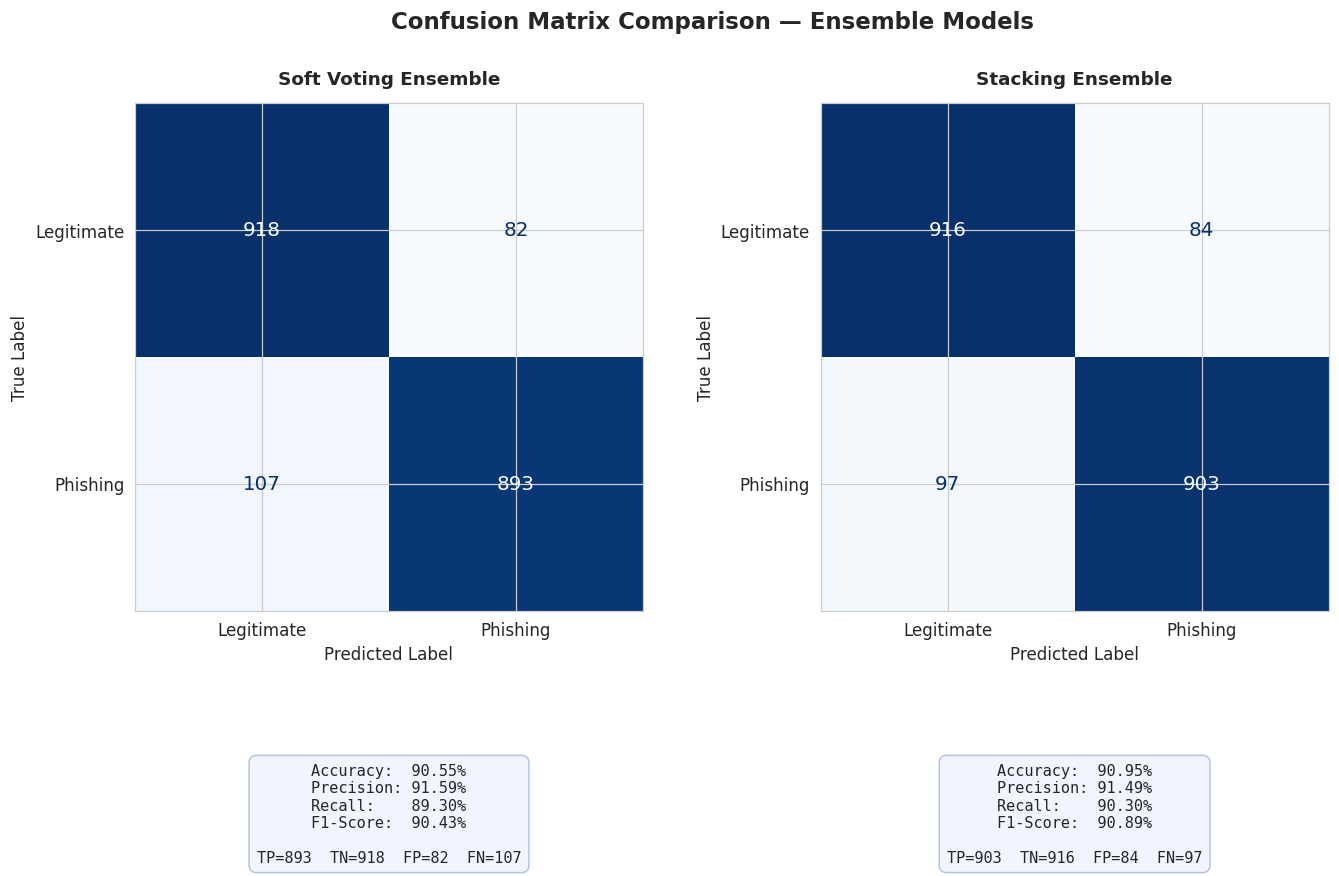

Saved → confusion_matrix_ensembles.png

Metric                     Voting       Stacking
Accuracy                   90.55%         90.95%  <-- better
Precision                  91.59%         91.49%  
Recall                     89.30%         90.30%  <-- better
F1-Score                   90.43%         90.89%  <-- better
-------------------------------------------------------
TP                            893            903
TN                            918            916
FP                             82             84
FN                            107             97


In [29]:
#  CONFUSION MATRIX — Voting & Stacking Ensemble
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ── Class labels (update if your dataset uses different names) ──
CLASS_NAMES = ["Legitimate", "Phishing"]

# ── Compute confusion matrices ───────────────────────────────
cm_vote  = confusion_matrix(y_test, y_pred_vote)
cm_stack = confusion_matrix(y_test, y_pred_stack)

# ── Helper: extract TP / TN / FP / FN ───────────────────────
def get_stats(cm):
    tn, fp, fn, tp = cm.ravel()
    return tn, fp, fn, tp


# ── Plot ──────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 6))
fig.suptitle("Confusion Matrix Comparison — Ensemble Models",
             fontsize=15, fontweight='bold', y=1.02)

gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)

for idx, (cm, title, y_pred) in enumerate([
    (cm_vote,  "Soft Voting Ensemble",   y_pred_vote),
    (cm_stack, "Stacking Ensemble",      y_pred_stack),
]):
    ax = fig.add_subplot(gs[idx])

    # Display the matrix with colour map
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=CLASS_NAMES)
    disp.plot(ax=ax, colorbar=False, cmap="Blues",
              values_format='d', text_kw={"fontsize": 13})

    tn, fp, fn, tp = get_stats(cm)
    total   = tn + fp + fn + tp
    accuracy  = (tp + tn) / total * 100
    precision = tp / (tp + fp) * 100 if (tp + fp) else 0
    recall    = tp / (tp + fn) * 100 if (tp + fn) else 0
    f1        = (2 * precision * recall / (precision + recall)
                 if (precision + recall) else 0)

    ax.set_title(title, fontsize=12, fontweight='bold', pad=12)
    ax.set_xlabel("Predicted Label", fontsize=11)
    ax.set_ylabel("True Label", fontsize=11)

    # Annotate stats below the matrix
    stats_text = (
        f"Accuracy:  {accuracy:.2f}%\n"
        f"Precision: {precision:.2f}%\n"
        f"Recall:    {recall:.2f}%\n"
        f"F1-Score:  {f1:.2f}%\n"
        f"\nTP={tp}  TN={tn}  FP={fp}  FN={fn}"
    )
    ax.text(0.5, -0.30, stats_text,
            transform=ax.transAxes,
            ha='center', va='top',
            fontsize=10, family='monospace',
            bbox=dict(boxstyle='round,pad=0.5',
                      facecolor='#f0f4ff', edgecolor='#aabbdd', alpha=0.85))

plt.tight_layout()
plt.savefig("confusion_matrix_ensembles.png", dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Saved → confusion_matrix_ensembles.png")


# ── Side-by-side text summary ─────────────────────────────────
print("\n" + "="*55)
print(f"{'Metric':<18} {'Voting':>14} {'Stacking':>14}")
print("="*55)

for cm, label in [(cm_vote, "voting"), (cm_stack, "stacking")]:
    tn, fp, fn, tp = get_stats(cm)
    total = tn + fp + fn + tp
    globals()[f"stats_{label}"] = {
        "Accuracy":  (tp + tn) / total * 100,
        "Precision": tp / (tp + fp) * 100 if (tp + fp) else 0,
        "Recall":    tp / (tp + fn) * 100 if (tp + fn) else 0,
        "F1-Score":  (2 * (tp/(tp+fp)) * (tp/(tp+fn)) /
                      ((tp/(tp+fp)) + (tp/(tp+fn)))) * 100
                     if (tp+fp) and (tp+fn) else 0,
        "TP": tp, "TN": tn, "FP": fp, "FN": fn,
    }

for metric in ["Accuracy", "Precision", "Recall", "F1-Score"]:
    v_val = stats_voting[metric]
    s_val = stats_stacking[metric]
    winner = "<-- better" if s_val >= v_val else ""
    print(f"{metric:<18} {v_val:>13.2f}% {s_val:>13.2f}%  {winner}")

print("-"*55)
for metric in ["TP", "TN", "FP", "FN"]:
    print(f"{metric:<18} {stats_voting[metric]:>14} {stats_stacking[metric]:>14}")
print("="*55)


 COMPLETE MODEL PERFORMANCE COMPARISON
 Rank               Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
    1   Stacking Ensemble    0.9095   0.909569  0.9095  0.909496 0.960793
    2   Gradient Boosting    0.9065   0.906999  0.9065  0.906471 0.961936
    3     Voting Ensemble    0.9055   0.905754  0.9055  0.905485 0.961545
    4             XGBoost    0.9045   0.904795  0.9045  0.904483 0.961391
    5       Random Forest    0.9035   0.903510  0.9035  0.903499 0.962545
    6 ANN (Deep Learning)    0.8935   0.897395  0.8935  0.893238 0.953647
    7                 SVM    0.8830   0.884886  0.8830  0.882856 0.939737
    8 Logistic Regression    0.8500   0.855466  0.8500  0.849421 0.928013

 BEST OVERALL MODEL : Stacking Ensemble
   Accuracy   : 0.9095 (90.95%)
   ROC-AUC    : 0.9608

 HIGHEST ROC-AUC MODEL
   Model      : Random Forest
   ROC-AUC    : 0.9625


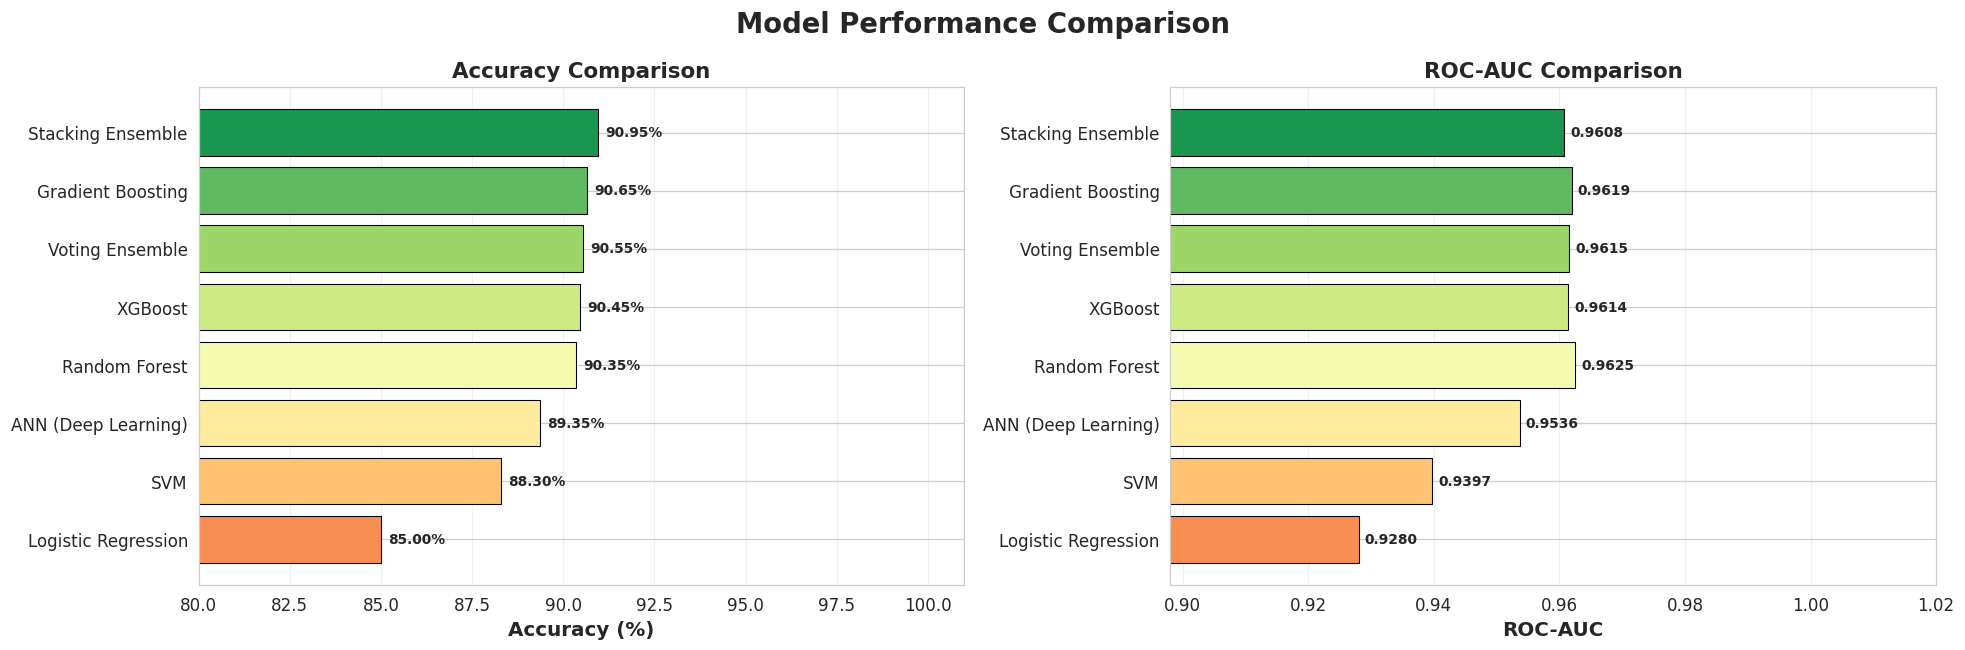

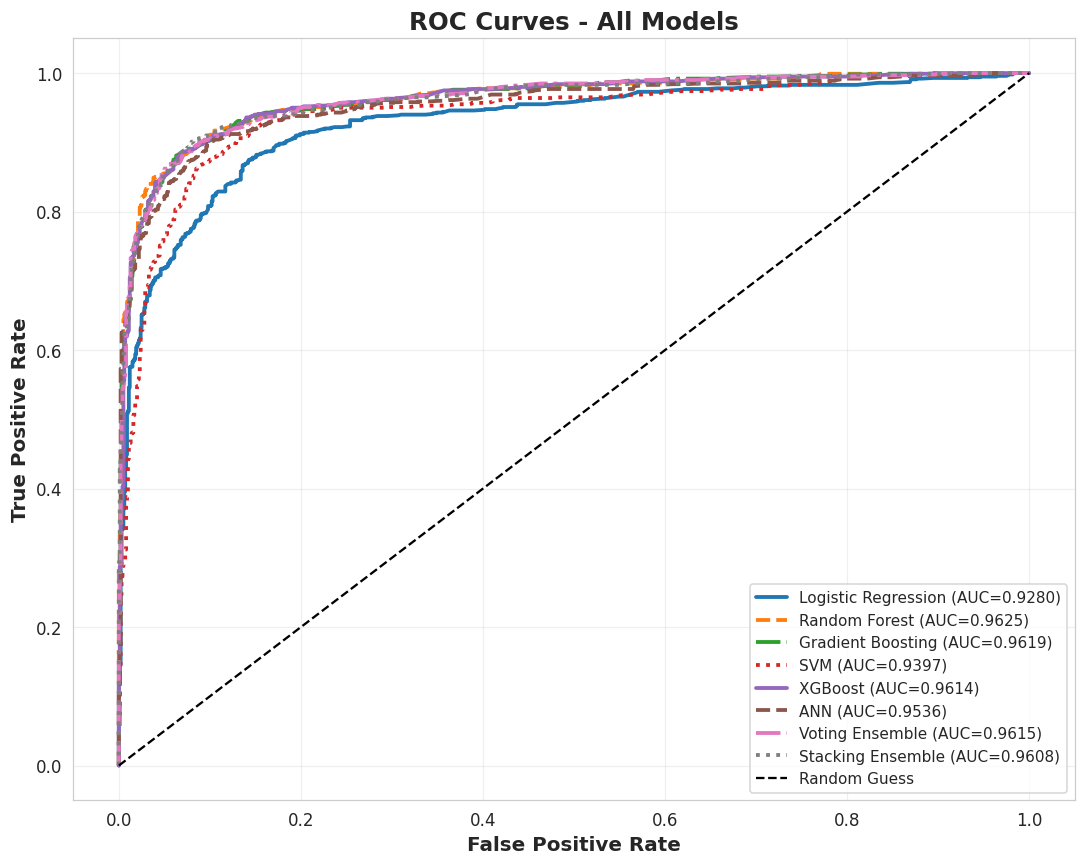

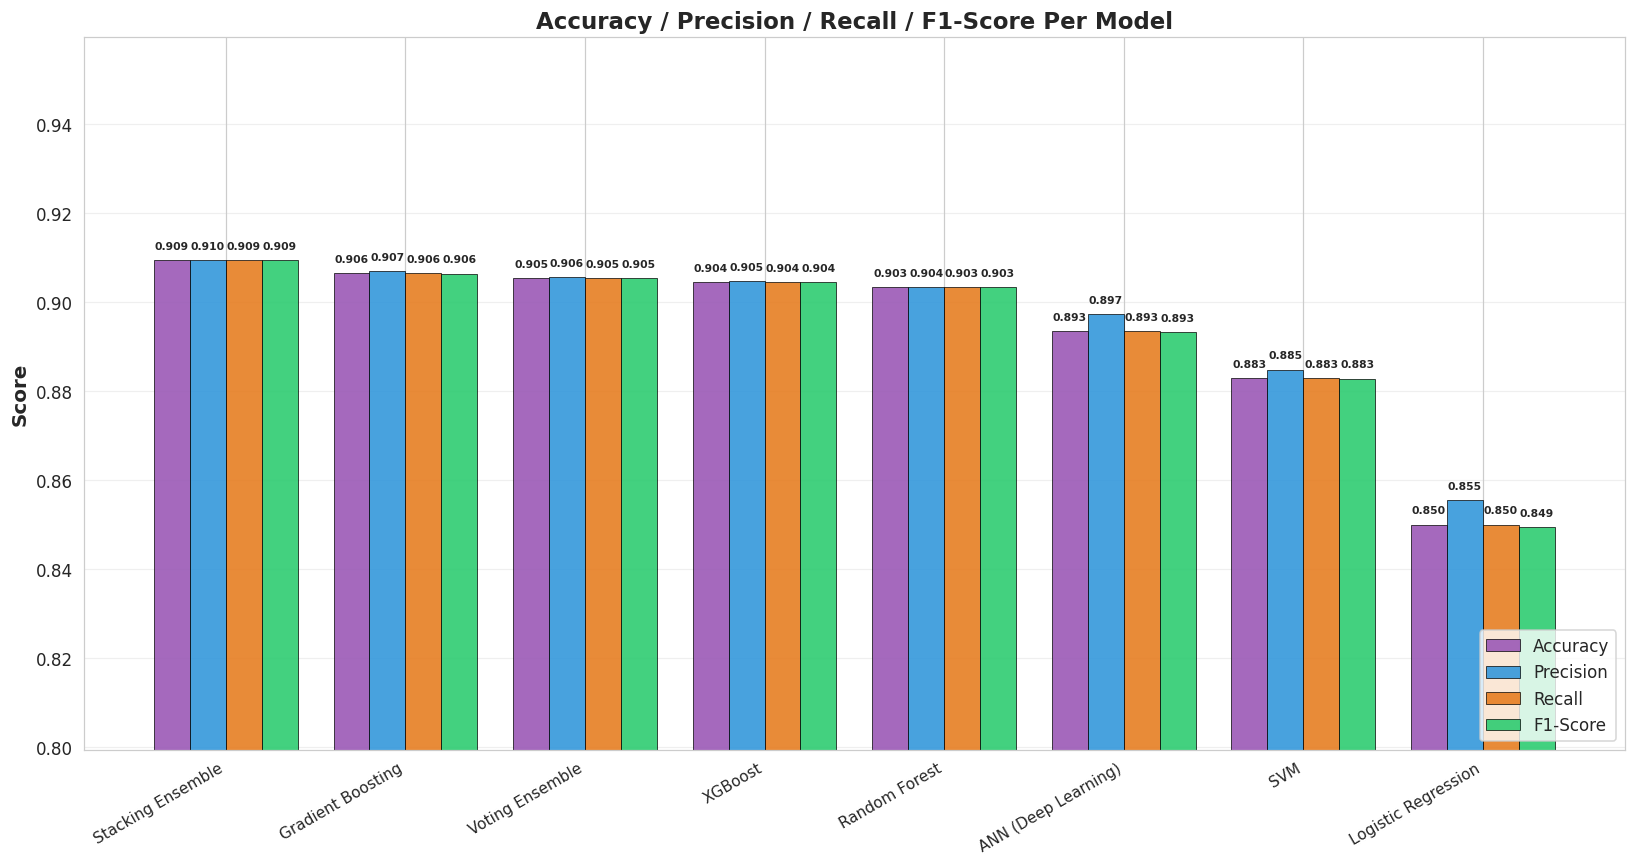


 Accuracy / Precision / Recall / F1 chart generated successfully!


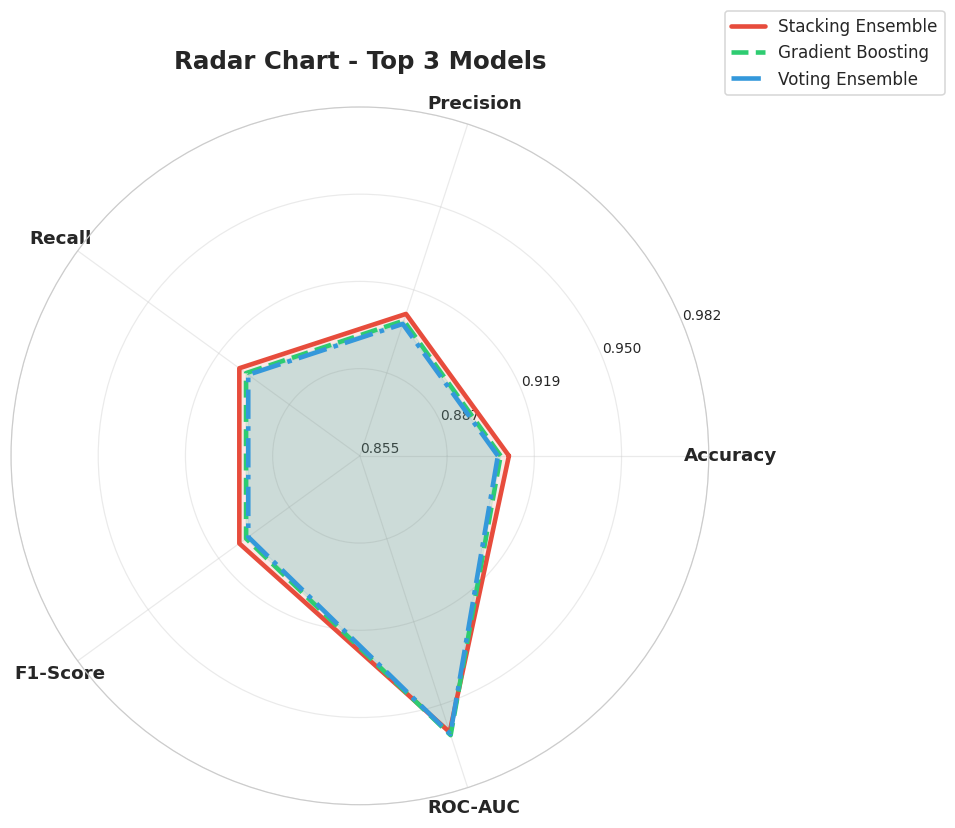


 Radar chart generated successfully!
 Top-3 models comparison completed!


In [ ]:
# COMPLETE PROFESSIONAL MODEL EVALUATION & VISUALIZATION

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# RESULTS TABLE
all_results_df = pd.DataFrame(results)

# Sort by overall classification performance
all_results_df = all_results_df.sort_values(
    by=['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    ascending=False
).reset_index(drop=True)

all_results_df.insert(0, 'Rank', range(1, len(all_results_df)+1))

print('\n' + '='*90)
print(' COMPLETE MODEL PERFORMANCE COMPARISON')
print('='*90)

print(
    all_results_df[
        ['Rank','Model','Accuracy','Precision',
         'Recall','F1-Score','ROC-AUC']
    ].to_string(index=False)
)

print('='*90)

# BEST OVERALL MODEL
best_model_name = all_results_df.iloc[0]['Model']
best_acc        = all_results_df.iloc[0]['Accuracy']
best_auc        = all_results_df.iloc[0]['ROC-AUC']

# Highest ROC-AUC model separately
highest_auc_idx = all_results_df['ROC-AUC'].idxmax()
highest_auc_model = all_results_df.iloc[highest_auc_idx]['Model']
highest_auc_score = all_results_df.iloc[highest_auc_idx]['ROC-AUC']

print(f'\n BEST OVERALL MODEL : {best_model_name}')
print(f'   Accuracy   : {best_acc:.4f} ({best_acc*100:.2f}%)')
print(f'   ROC-AUC    : {best_auc:.4f}')

print('\n HIGHEST ROC-AUC MODEL')
print(f'   Model      : {highest_auc_model}')
print(f'   ROC-AUC    : {highest_auc_score:.4f}')

# CHART 1 : ACCURACY + ROC-AUC COMPARISON
n_models = len(all_results_df)
colors = plt.cm.RdYlGn(
    np.linspace(0.25, 0.9, n_models)
)[::-1]
fig, axes = plt.subplots(
    1, 2,
    figsize=(18, max(6, n_models*0.7))
)

fig.suptitle(
    'Model Performance Comparison',
    fontsize=18,
    fontweight='bold'
)

# Accuracy Graph
ax = axes[0]

bars = ax.barh(
    all_results_df['Model'],
    all_results_df['Accuracy'] * 100,
    color=colors,
    edgecolor='black',
    linewidth=0.7
)

acc_min = all_results_df['Accuracy'].min() * 100

ax.set_xlim([max(0, acc_min - 5), 101])

ax.set_xlabel(
    'Accuracy (%)',
    fontsize=13,
    fontweight='bold'
)

ax.set_title(
    'Accuracy Comparison',
    fontsize=14,
    fontweight='bold'
)

for bar, val in zip(bars, all_results_df['Accuracy']):

    ax.text(
        val*100 + 0.2,
        bar.get_y() + bar.get_height()/2,
        f'{val*100:.2f}%',
        va='center',
        fontsize=9,
        fontweight='bold'
    )

ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

# ROC-AUC Graph
ax = axes[1]

bars = ax.barh(
    all_results_df['Model'],
    all_results_df['ROC-AUC'],
    color=colors,
    edgecolor='black',
    linewidth=0.7
)

auc_min = all_results_df['ROC-AUC'].min()

ax.set_xlim([max(0, auc_min - 0.03), 1.02])

ax.set_xlabel(
    'ROC-AUC',
    fontsize=13,
    fontweight='bold'
)

ax.set_title(
    'ROC-AUC Comparison',
    fontsize=14,
    fontweight='bold'
)

for bar, val in zip(bars, all_results_df['ROC-AUC']):

    ax.text(
        val + 0.001,
        bar.get_y() + bar.get_height()/2,
        f'{val:.4f}',
        va='center',
        fontsize=9,
        fontweight='bold'
    )

ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()

plt.savefig(
    'model_comparison.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# CHART 2 : ROC CURVES FOR ALL MODELS
fig, ax = plt.subplots(figsize=(10,8))
line_styles = ['-','--','-.',':']
for i, (name, (y_prob, auc)) in enumerate(roc_data.items()):

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    ax.plot(
        fpr,
        tpr,
        lw=2.5,
        linestyle=line_styles[i % len(line_styles)],
        label=f'{name} (AUC={auc:.4f})'
    )

ax.plot(
    [0,1],
    [0,1],
    'k--',
    lw=1.5,
    label='Random Guess'
)

ax.set_xlabel(
    'False Positive Rate',
    fontsize=13,
    fontweight='bold'
)

ax.set_ylabel(
    'True Positive Rate',
    fontsize=13,
    fontweight='bold'
)

ax.set_title(
    'ROC Curves - All Models',
    fontsize=16,
    fontweight='bold'
)

ax.legend(
    fontsize=10,
    loc='lower right'
)

ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    'roc_all_models.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# CHART 3 : ACCURACY / PRECISION / RECALL / F1
metrics_to_plot = [
    'Accuracy',
    'Precision',
    'Recall',
    'F1-Score'
]

n = len(all_results_df)

x = np.arange(n)

width = 0.2

bar_colors = [
    '#9B59B6',
    '#3498DB',
    '#E67E22',
    '#2ECC71'
]

fig, ax = plt.subplots(
    figsize=(max(15, n*1.8), 8)
)

for i, (metric, color) in enumerate(
    zip(metrics_to_plot, bar_colors)
):

    offset = (i - 1.5) * width

    bars = ax.bar(
        x + offset,
        all_results_df[metric],
        width,
        label=metric,
        color=color,
        alpha=0.9,
        edgecolor='black',
        linewidth=0.5
    )

    for bar in bars:

        h = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width()/2,
            h + 0.002,
            f'{h:.3f}',
            ha='center',
            va='bottom',
            fontsize=7,
            fontweight='bold'
        )

ax.set_xticks(x)

ax.set_xticklabels(
    all_results_df['Model'],
    rotation=30,
    ha='right',
    fontsize=10
)

ax.set_ylabel(
    'Score',
    fontsize=13,
    fontweight='bold'
)

ax.set_title(
    'Accuracy / Precision / Recall / F1-Score Per Model',
    fontsize=15,
    fontweight='bold'
)

ax.legend(
    fontsize=11,
    loc='lower right'
)

ymin = min(all_results_df[metrics_to_plot].min()) - 0.05
ymax = min(1.02, max(all_results_df[metrics_to_plot].max()) + 0.05)

ax.set_ylim([max(0, ymin), ymax])

ax.grid(axis='y', alpha=0.3)

plt.tight_layout()

plt.savefig(
    'metrics_comparison.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print('\n Accuracy / Precision / Recall / F1 chart generated successfully!')
# CHART 4 : RADAR CHART - TOP 3 MODELS
top3 = all_results_df.head(3)

radar_metrics = [
    'Accuracy',
    'Precision',
    'Recall',
    'F1-Score',
    'ROC-AUC'
]

angles = np.linspace(
    0,
    2*np.pi,
    len(radar_metrics),
    endpoint=False
).tolist()

angles += angles[:1]

fig, ax = plt.subplots(
    figsize=(9,9),
    subplot_kw=dict(polar=True)
)

radar_colors = [
    '#E74C3C',
    '#2ECC71',
    '#3498DB'
]

radar_styles = [
    '-',
    '--',
    '-.'
]

# Dynamic scaling

all_radar_vals = [
    top3.iloc[i][m]
    for i in range(len(top3))
    for m in radar_metrics
]

r_min = max(0, min(all_radar_vals) - 0.05)
r_max = min(1.0, max(all_radar_vals) + 0.02)

for i, (_, row) in enumerate(top3.iterrows()):

    vals = [row[m] for m in radar_metrics]

    vals += vals[:1]

    ax.plot(
        angles,
        vals,
        color=radar_colors[i],
        linewidth=3,
        linestyle=radar_styles[i],
        label=row['Model']
    )

    ax.fill(
        angles,
        vals,
        color=radar_colors[i],
        alpha=0.12
    )

ax.set_xticks(angles[:-1])

ax.set_xticklabels(
    radar_metrics,
    fontsize=12,
    fontweight='bold'
)

ax.set_ylim([r_min, r_max])

ax.set_yticks(
    np.linspace(r_min, r_max, 5)
)

ax.set_yticklabels(
    [
        f'{v:.3f}'
        for v in np.linspace(r_min, r_max, 5)
    ],
    fontsize=9
)

ax.set_title(
    'Radar Chart - Top 3 Models',
    fontsize=16,
    fontweight='bold',
    pad=25
)

ax.legend(
    loc='upper right',
    bbox_to_anchor=(1.35, 1.15),
    fontsize=11
)

ax.grid(alpha=0.4)

plt.tight_layout()

plt.savefig(
    'radar_chart.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print('\n Radar chart generated successfully!')
print(' Top-3 models comparison completed!')

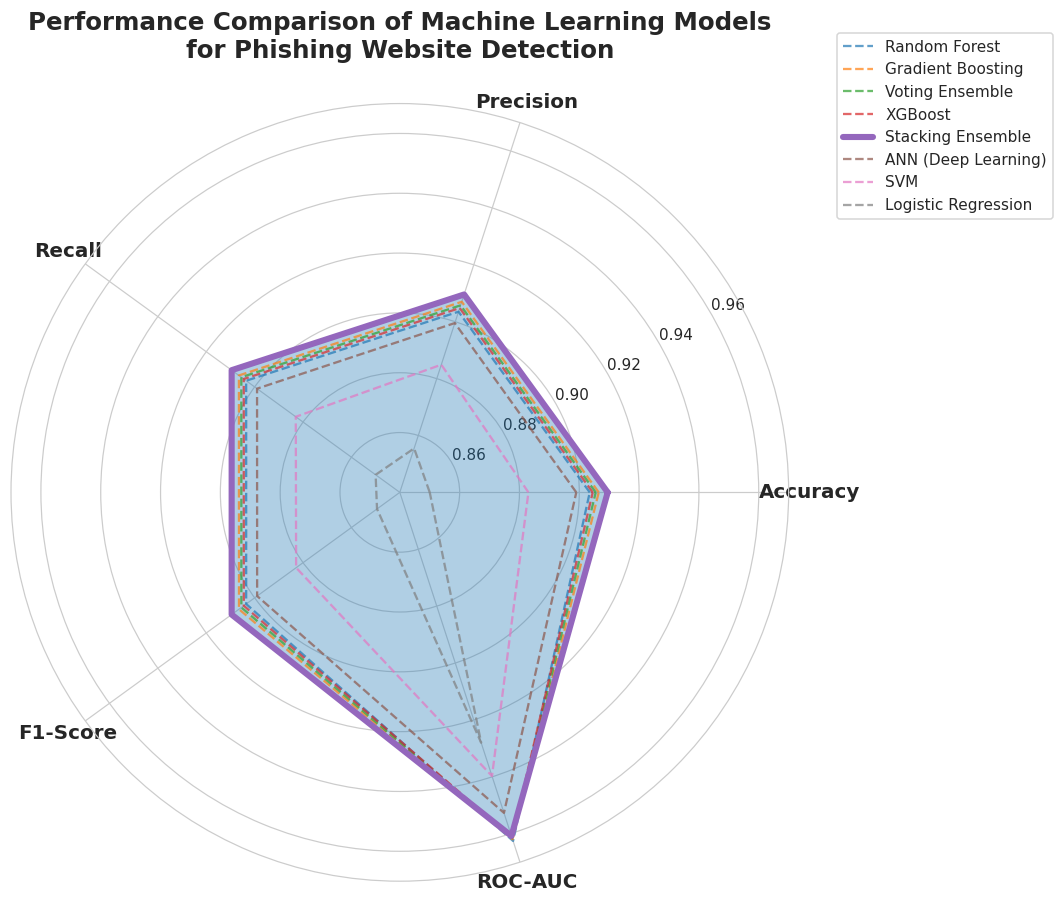

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# COMPLETE MODEL PERFORMANCE DATA (YOUR ACTUAL RESULTS)
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

model_scores = {

    'Random Forest': [
        0.9035,
        0.903510,
        0.9035,
        0.903499,
        0.962545
    ],

    'Gradient Boosting': [
        0.9065,
        0.906999,
        0.9065,
        0.906471,
        0.961936
    ],

    'Voting Ensemble': [
        0.9055,
        0.905754,
        0.9055,
        0.905485,
        0.961545
    ],

    'XGBoost': [
        0.9045,
        0.904795,
        0.9045,
        0.904483,
        0.961391
    ],

    # BEST MODEL → STACKING ENSEMBLE

    'Stacking Ensemble': [
        0.9095,
        0.909569,
        0.9095,
        0.909496,
        0.960793
    ],

    'ANN (Deep Learning)': [
        0.8990,
        0.899518,
        0.8990,
        0.898967,
        0.952672
    ],

    'SVM': [
        0.8830,
        0.884886,
        0.8830,
        0.882856,
        0.939737
    ],

    'Logistic Regression': [
        0.8500,
        0.855466,
        0.8500,
        0.849421,
        0.928013
    ]
}
# RADAR CHART SETUP
N = len(metrics)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
# Close radar chart
angles += angles[:1]
# CREATE FIGURE
fig, ax = plt.subplots(
    figsize=(10, 10),
    subplot_kw=dict(polar=True)
)
# PLOT MODELS
for model, scores in model_scores.items():

    values = scores + scores[:1]

    # Highlight Stacking Ensemble
    if model == 'Stacking Ensemble':

        ax.plot(
            angles,
            values,
            linewidth=4,
            linestyle='solid',
            label=model
        )

        ax.fill(
            angles,
            values,
            alpha=0.35
        )

    else:

        ax.plot(
            angles,
            values,
            linewidth=1.5,
            linestyle='dashed',
            alpha=0.7,
            label=model
        )
# AXIS SETTINGS
ax.set_xticks(angles[:-1])

ax.set_xticklabels(
    metrics,
    fontsize=13,
    fontweight='bold'
)

# Better scaling to visually enlarge differences
ax.set_ylim(0.84, 0.97)

# Radial labels
ax.set_rlabel_position(30)

plt.yticks(
    [0.86, 0.88, 0.90, 0.92, 0.94, 0.96],
    fontsize=10
)
# TITLE
plt.title(
    'Performance Comparison of Machine Learning Models\nfor Phishing Website Detection',
    fontsize=16,
    fontweight='bold',
    pad=30
)
# LEGEND
plt.legend(
    loc='upper right',
    bbox_to_anchor=(1.35, 1.10),
    fontsize=10
)
# GRID
ax.grid(True)
# SHOW CHART
plt.tight_layout()
plt.show()

Computing SHAP values (TreeExplainer on Random Forest)...
   SHAP values shape: (500, 30)


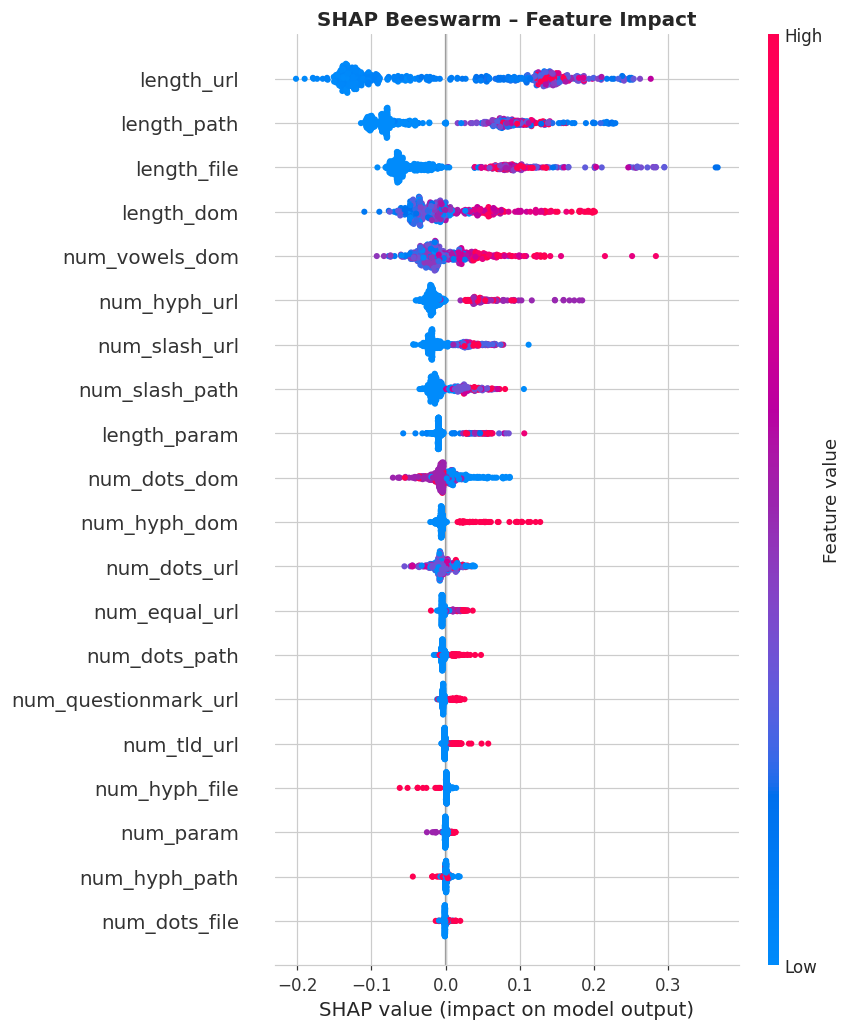

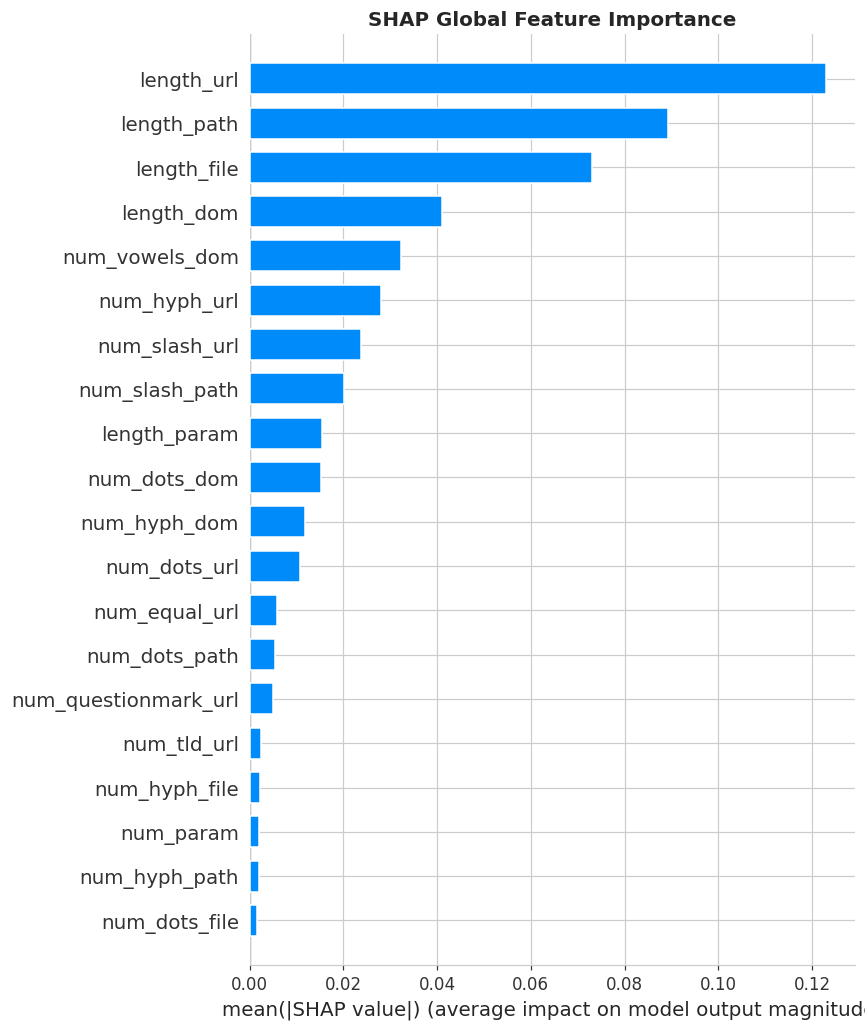

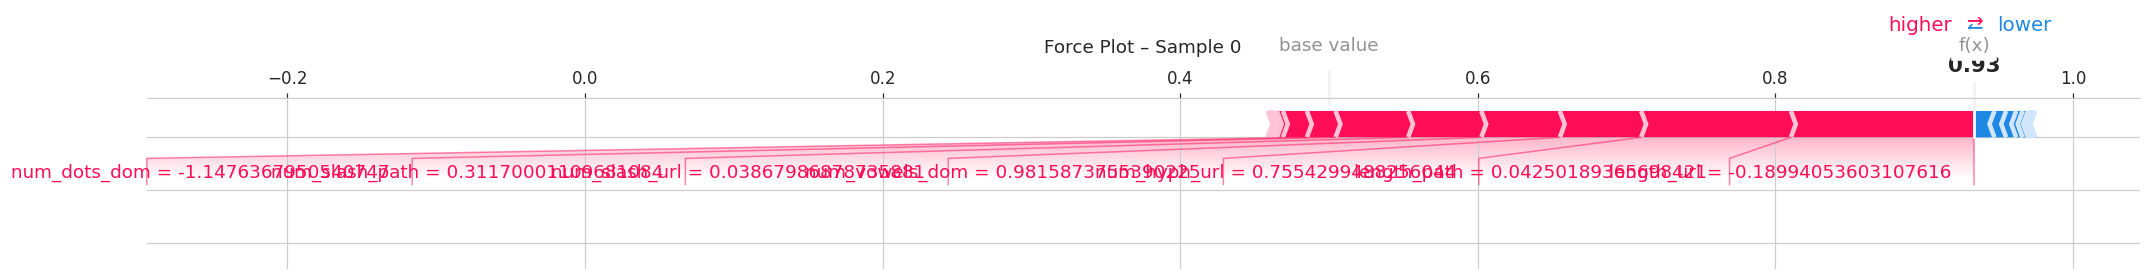


Top 10 Most Influential Features (SHAP):
       Feature  Mean |SHAP|
    length_url     0.122966
   length_path     0.089255
   length_file     0.073062
    length_dom     0.040984
num_vowels_dom     0.032348
  num_hyph_url     0.027925
 num_slash_url     0.023718
num_slash_path     0.020126
  length_param     0.015501
  num_dots_dom     0.015244


In [ ]:
import shap
shap.initjs()

print('Computing SHAP values (TreeExplainer on Random Forest)...')

N_SHAP  = min(500, X_test_sel.shape[0])
np.random.seed(RANDOM_STATE)
shap_idx = np.random.choice(X_test_sel.shape[0], N_SHAP, replace=False)
X_shap   = X_test_sel[shap_idx]

shap_feat_df = pd.DataFrame(X_shap, columns=selected_features)
explainer    = shap.TreeExplainer(rf_model)
shap_values  = explainer.shap_values(X_shap)

# Binary classification → use class 1
# The explainer for a multi-output model returns a 3D array (samples, features, classes)
# To get SHAP values for class 1, we need to slice the last dimension.
if isinstance(shap_values, list):
    # This case is for models that output a list of arrays
    sv = shap_values[1]
elif shap_values.ndim == 3:
    # This case is for TreeExplainer on multi-output models (e.g., Random Forest Classifier)
    sv = shap_values[:, :, 1]
else:
    # For single-output models, shap_values is already 2D
    sv = shap_values

print(f'   SHAP values shape: {sv.shape}')

# Beeswarm
plt.figure(figsize=(10,7))
shap.summary_plot(sv, shap_feat_df, plot_type='dot', show=False, max_display=20)
plt.title('SHAP Beeswarm – Feature Impact', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('shap_beeswarm.png', bbox_inches='tight'); plt.show()

# Bar
plt.figure(figsize=(9,6))
shap.summary_plot(sv, shap_feat_df, plot_type='bar', show=False, max_display=20)
plt.title('SHAP Global Feature Importance', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('shap_bar.png', bbox_inches='tight'); plt.show()

# Force plot (single sample)
# For binary classification (class 1), explainer.expected_value is an array of two values.
# We need the expected value for class 1 (index 1).
exp_val = explainer.expected_value[1]
force_fig = shap.force_plot(exp_val, sv[0], shap_feat_df.iloc[0], matplotlib=True, show=False)
# Set title directly on the figure's axes (assuming force_plot creates a single axes)
if force_fig is not None and len(force_fig.axes) > 0:
    force_fig.axes[0].set_title('Force Plot – Sample 0', fontsize=12, pad=30)
force_fig.tight_layout()
force_fig.savefig('shap_force_plot.png', bbox_inches='tight')
plt.show()

# Top features table
mean_abs = np.abs(sv).mean(axis=0)
shap_df  = pd.DataFrame({'Feature': selected_features, 'Mean |SHAP|': mean_abs})
shap_df  = shap_df.sort_values('Mean |SHAP|', ascending=False).head(10)
print('''
Top 10 Most Influential Features (SHAP):''')
print(shap_df.to_string(index=False))

In [28]:
import joblib

MODEL_OBJECTS = {
    'Random Forest':      rf_model,
    'XGBoost':            xgb_model,
    'Logistic Regression':lr_model,
    'SVM':                svm_model,
    'Voting Ensemble':    voting_model,
    'Stacking Ensemble':  stacking_model,
}

for mname, mobj in MODEL_OBJECTS.items():
    fname = mname.lower().replace(' ','_') + '_model.pkl'
    joblib.dump(mobj, fname)
    print(f'Saved: {fname}')

joblib.dump(scaler,           'feature_scaler.pkl')
joblib.dump(rfe,              'rfe_selector.pkl')
joblib.dump(selected_features,'selected_features.pkl')
ann_model.save('ann_model.keras')
all_results_df.to_csv('phishing_model_results.csv', index=False)

print('\n All models, scaler, RFE, and results saved!')

Saved: random_forest_model.pkl
Saved: xgboost_model.pkl
Saved: logistic_regression_model.pkl
Saved: svm_model.pkl
Saved: voting_ensemble_model.pkl
Saved: stacking_ensemble_model.pkl

 All models, scaler, RFE, and results saved!


In [26]:
#  PHISHING URL CHECKER
#  Model: Stacking Ensemble | Accuracy: 90.95%

# ── STEP 1: Import Libraries ─────────────────────────────────
import joblib           # To load saved model files (.pkl)
import numpy as np      # For numerical arrays
import re               # For pattern matching (regex)
from urllib.parse import urlparse  # To break URL into parts

# ── STEP 2: Load the Saved Model Files ───────────────────────
# These .pkl files were saved after training in the notebook
model    = joblib.load("stacking_ensemble_model.pkl")  # The trained stacking ensemble
scaler   = joblib.load("feature_scaler.pkl")            # StandardScaler (normalizes features)
rfe      = joblib.load("rfe_selector.pkl")              # Recursive Feature Elimination selector
features = joblib.load("selected_features.pkl")         # List of best feature names

print(f"Model loaded. Uses {rfe.n_features_in_} input features → selects {len(features)} best.")


# ── STEP 3: Feature Extraction Function ──────────────────────
# Given a URL string, extract numeric features the model understands
def extract_features(url):
    # Parse the URL into components (scheme, hostname, path, query)
    try:
        parsed = urlparse(url if url.startswith("http") else "http://" + url)
    except:
        parsed = urlparse("http://invalid")

    hostname = parsed.hostname or ""
    path     = parsed.path     or ""
    query    = parsed.query    or ""
    n        = max(1, len(url))   # total URL length (avoid divide-by-zero)

    # Count digit and letter characters
    n_digits  = sum(c.isdigit() for c in url)
    n_letters = sum(c.isalpha() for c in url)

    # Suspicious keywords commonly found in phishing URLs
    KEYWORDS = [
        "login", "signin", "account", "update", "secure", "banking",
        "verify", "password", "confirm", "paypal", "ebay", "amazon",
        "apple", "microsoft", "support", "alert", "free", "prize",
        "winner", "urgent", "click", "suspended"
    ]

    # URL shortener domains (used to hide malicious links)
    SHORTENERS = [
        "bit.ly", "tinyurl", "goo.gl", "ow.ly", "t.co",
        "buff.ly", "adf.ly", "is.gd", "tiny.cc", "cutt.ly"
    ]

    # Build a list of numeric features (same order as training data)
    features_list = [
        # --- Length-based features ---
        len(url),                                           # Total URL length
        len(hostname),                                      # Hostname length
        len(path),                                          # Path length
        len(query),                                         # Query string length

        # --- Character count features ---
        url.count("."),     # Number of dots
        url.count("-"),     # Number of hyphens
        url.count("_"),     # Underscores
        url.count("/"),     # Forward slashes
        url.count("?"),     # Question marks
        url.count("="),     # Equals signs
        url.count("@"),     # @ symbol (suspicious — redirects to different host)
        url.count("&"),     # Ampersands
        url.count("!"),
        url.count(" "),
        url.count("~"),
        url.count(","),
        url.count("+"),
        url.count("*"),
        url.count("#"),
        url.count("$"),
        url.count("%"),
        n_digits,           # Total digit count
        n_letters,          # Total letter count

        # --- Binary (yes/no) features ---
        1 if parsed.scheme == "https" else 0,               # Is HTTPS? (safe = 1)
        1 if re.match(r"^\d{1,3}(\.\d{1,3}){3}$",
                      hostname) else 0,                     # Is IP address? (suspicious = 1)
        1 if "@" in url else 0,                             # Has @ symbol?
        1 if "//" in path else 0,                           # Double slash in path?
        1 if "-" in hostname else 0,                        # Hyphen in hostname?
        max(0, len(hostname.split(".")) - 2),               # Number of subdomains
        1 if any(s in hostname for s in SHORTENERS) else 0, # Is a URL shortener?

        # --- Ratio features ---
        n_digits  / n,                                      # Digit ratio
        n_letters / n,                                      # Letter ratio
        (n - n_digits - n_letters) / n,                    # Special character ratio

        # --- Hostname-level features ---
        sum(c.isdigit() for c in hostname),                 # Digits in hostname
        hostname.count("-"),                                # Hyphens in hostname
        hostname.count("."),                                # Dots in hostname

        # --- Keyword feature ---
        1 if any(kw in url.lower() for kw in KEYWORDS) else 0  # Suspicious keyword?
    ]

    arr = np.array(features_list, dtype=float)

    # Pad or trim to match the exact size the scaler expects
    expected = rfe.n_features_in_
    if len(arr) < expected:
        arr = np.pad(arr, (0, expected - len(arr)))   # Add zeros at the end
    else:
        arr = arr[:expected]                           # Trim extra values

    return arr


# ── STEP 4: Prediction Function ───────────────────────────────
# Takes a URL → returns label and probability
def predict_url(url):
    # Step 4a: Extract raw numeric features
    raw_features = extract_features(url)

    # Step 4b: Scale features (mean=0, std=1) using the saved scaler
    scaled = scaler.transform(raw_features.reshape(1, -1))

    # Step 4c: Apply RFE to select only the best features
    selected = rfe.transform(scaled)

    # Step 4d: Get probability of being phishing (class = 1)
    probability = model.predict_proba(selected)[0, 1]

    # Step 4e: Apply threshold — if >= 50% chance → PHISHING
    label = "PHISHING" if probability >= 0.5 else "LEGITIMATE"

    return label, probability


# ── STEP 5: Test with Example URLs ────────────────────────────
legitimate_urls = [
    "https://www.google.com",
    "https://www.microsoft.com",
    "https://www.amazon.com",
    "https://www.apple.com",
    "https://www.github.com",
    "https://www.stackoverflow.com",
    "https://www.wikipedia.org",
    "https://www.linkedin.com",
    "https://www.netflix.com",
    "https://www.paypal.com",
]

phishing_urls = [
    "http://paypal-login-security-update.com",
    "http://amaz0n-verification.net",
    "http://secure-facebook-login.xyz",
    "http://google-account-reset.tk",
    "http://microsoft-support-alert.ml",
    "http://appleid-confirm-password.ga",
    "http://banking-secure-login.cf",
    "http://free-netflix-premium.gq",
    "http://instagram-followers-free.xyz",
    "http://verify-paytm-account.ml",
]

print("\n" + "="*60)
print("  PHISHING URL CHECKER — Results")
print("="*60)

print("\n[Legitimate URLs]")
for url in legitimate_urls:
    label, prob = predict_url(url)
    print(f"  {'✓' if label == 'LEGITIMATE' else '✗'}  {label} ({prob*100:.1f}%)  →  {url}")

print("\n[Phishing URLs]")
for url in phishing_urls:
    label, prob = predict_url(url)
    print(f"  {'✓' if label == 'PHISHING' else '✗'}  {label} ({prob*100:.1f}%)  →  {url}")

print("\n" + "="*60)


# ── STEP 6: Interactive Single URL Check ─────────────────────
# Run this to check any URL manually
def check_single_url(url):
    label, prob = predict_url(url)
    print(f"\nURL     : {url}")
    print(f"Result  : {label}")
    print(f"Phishing probability: {prob*100:.1f}%")
    if label == "PHISHING":
        print("WARNING: This URL looks suspicious. Do NOT visit it.")
    else:
        print("This URL appears safe.")

# Example usage:
# check_single_url("https://www.google.com")
# check_single_url("http://paypal-login-security-update.com")

Model loaded. Uses 74 input features → selects 30 best.

  PHISHING URL CHECKER — Results

[Legitimate URLs]
  ✗  PHISHING (72.4%)  →  https://www.google.com
  ✗  PHISHING (74.2%)  →  https://www.microsoft.com
  ✗  PHISHING (72.4%)  →  https://www.amazon.com
  ✗  PHISHING (72.4%)  →  https://www.apple.com
  ✗  PHISHING (72.4%)  →  https://www.github.com
  ✗  PHISHING (72.4%)  →  https://www.stackoverflow.com
  ✗  PHISHING (72.4%)  →  https://www.wikipedia.org
  ✗  PHISHING (72.4%)  →  https://www.linkedin.com
  ✗  PHISHING (72.4%)  →  https://www.netflix.com
  ✗  PHISHING (72.4%)  →  https://www.paypal.com

[Phishing URLs]
  ✓  PHISHING (77.8%)  →  http://paypal-login-security-update.com
  ✓  PHISHING (85.4%)  →  http://amaz0n-verification.net
  ✓  PHISHING (77.8%)  →  http://secure-facebook-login.xyz
  ✓  PHISHING (77.8%)  →  http://google-account-reset.tk
  ✓  PHISHING (77.8%)  →  http://microsoft-support-alert.ml
  ✓  PHISHING (77.8%)  →  http://appleid-confirm-password.ga
  ✓  PHIS